# Mesh operations with meshio++ (C++ / xeus-cpp)

C++ counterpart of
[`03_mesh_operations.ipynb`](../example/03_mesh_operations.ipynb): the same
tour of meshio++'s dependency-free **operations layer**
(`src/cpp/include/meshioplusplus/operations/`), called directly in C++ instead
of through the Python bindings — every operation shown here is the exact
function the Python/C-API/Fortran/WASM bindings and the CLI verbs all call
into. Renders go through `mio_notebook.hpp`'s `render()` (meshio++'s own
SVG writer) rather than PyVista; see
[`01_read_and_visualize.ipynb`](./01_read_and_visualize.ipynb) for why.

One deliberate departure from the Python notebook: several colour-by
choices below use `quality:aspect_ratio` rather than
`quality:scaled_jacobian` on a *pure triangle surface* mesh — the scaled
Jacobian metric legitimately evaluates to NaN there (confirmed identical in
the Python bindings; it is a property of the metric on that cell type/mesh
shape combination, not a C++-vs-Python difference), so a non-degenerate
metric makes for a more informative figure.

In [1]:
#define MESHIOPLUSPLUS_IMPLEMENTATION
#include "../../src/single_include/meshioplusplus/meshioplusplus.hpp"
#include "mio_notebook.hpp"
#include <iostream>
#include <iomanip>
#include <cmath>
#include <algorithm>
#include <numeric>
#include <random>
#include <chrono>

#ifndef M_PI
#define M_PI 3.14159265358979323846
#endif

using namespace meshioplusplus;
using namespace mio_nb;

In [2]:
Mesh mesh = registry_read("example.vtu", resolve_format("example.vtu", ""), {});
std::cout << "points: " << mesh.NumPoints() << ", triangles: " << mesh.Cells(0).NumCells()
          << ", tetrahedra: " << mesh.Cells(1).NumCells() << "\n";

points: 52282, triangles: 58394, tetrahedra: 235014


## Surface / skin extraction

`extract_surface` picks the boundary automatically from the mesh's own
highest-dimension cells (here: the tetrahedra); `extract_skin` is the
volume-only variant with an explicit `linearize` flag. Both are implemented
by the same code path (`operations/surface.cpp`).

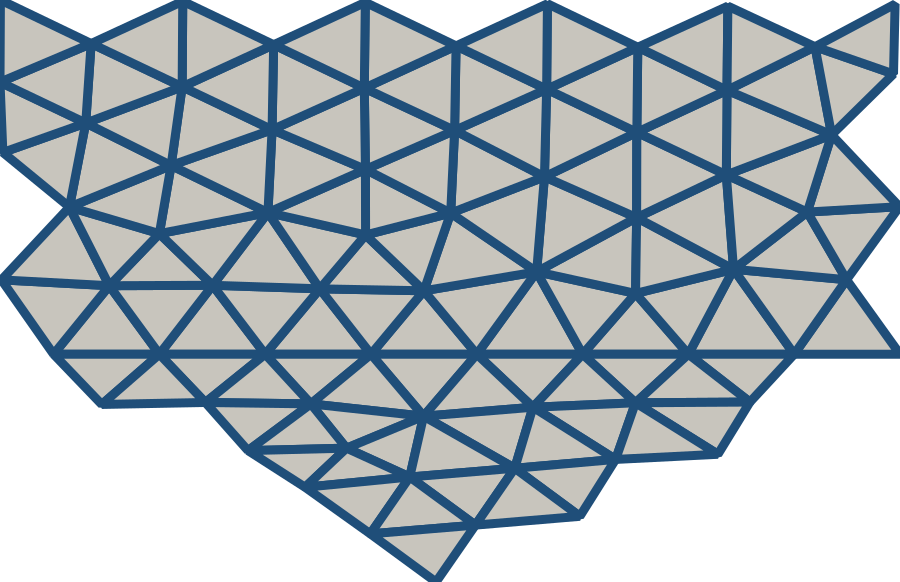

surface: triangle x 58394
skin   : triangle x 58394


In [3]:
Mesh surface = extract_surface(mesh);
Mesh skin = extract_skin(mesh, /*linearize=*/true);
std::cout << "surface: " << surface.Cells(0).Type() << " x " << surface.Cells(0).NumCells() << "\n";
std::cout << "skin   : " << skin.Cells(0).Type() << " x " << skin.Cells(0).NumCells() << "\n";

// A vector figure's size scales with facet count (unlike a raster PNG), so
// renders below crop to a legible corner -- the same trade-off documented
// for tools/gen_doc_images.py: the full ~58k-facet skin makes a multi-MB SVG
// whose individual elements are sub-pixel.
double vizLo[3], vizHi[3];
{
    auto vs = compute_stats(surface);
    for (int d = 0; d < 3; ++d) { vizLo[d] = vs.mBBoxMin[d]; vizHi[d] = vs.mBBoxMax[d]; }
}
double vizCornerHi[3];
for (int d = 0; d < 3; ++d) vizCornerHi[d] = vizLo[d] + (vizHi[d] - vizLo[d]) * 0.35;
Mesh vizCorner = crop_bbox(surface, vizLo, vizCornerHi, CropMode::All, false).mMesh;

xcpp::display(render(vizCorner));

## Quality metrics

`compute_quality` scores every cell on a set of geometric metrics (and
flags inverted/degenerate cells); `attach_quality` writes them back as
`cell_data`. Below: the distribution of `aspect_ratio` over the whole
surface (1.0 = equilateral, the metric's ideal value), then the boundary
coloured by its own per-triangle aspect ratio.

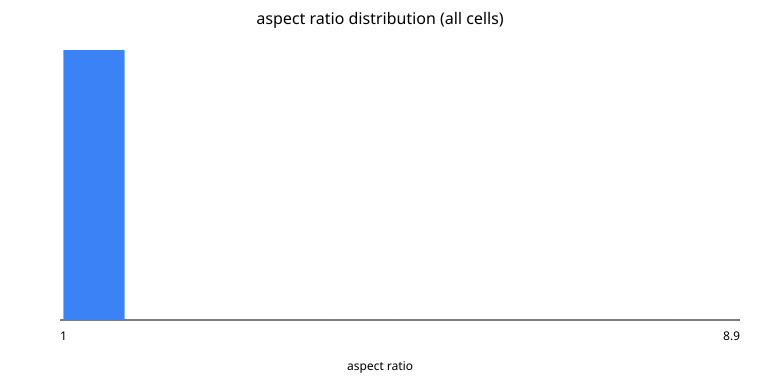

cells scored: 58394, inverted: 0
quality:aspect_ratio min=1 mean=1.0292 max=8.90081


In [4]:
QualityReport report = compute_quality(surface);
std::cout << "cells scored: " << report.mNumCells << ", inverted: " << report.mNumInverted << "\n";
const QualityMetricSummary* ar = nullptr;
for (auto& [name, summary] : report.mMetrics)
    if (name == "quality:aspect_ratio") ar = &summary;
std::cout << "quality:aspect_ratio min=" << ar->mMin << " mean=" << ar->mMean << " max=" << ar->mMax << "\n";

std::vector<double> edges(QualityMetricSummary::K + 1);
for (int i = 0; i <= QualityMetricSummary::K; ++i) edges[i] = ar->mMin + (ar->mMax - ar->mMin) * i / QualityMetricSummary::K;
std::vector<std::int64_t> counts(ar->mHistogram.begin(), ar->mHistogram.end());
xcpp::display(histogram_chart(edges, counts, "aspect ratio distribution (all cells)", "aspect ratio"));

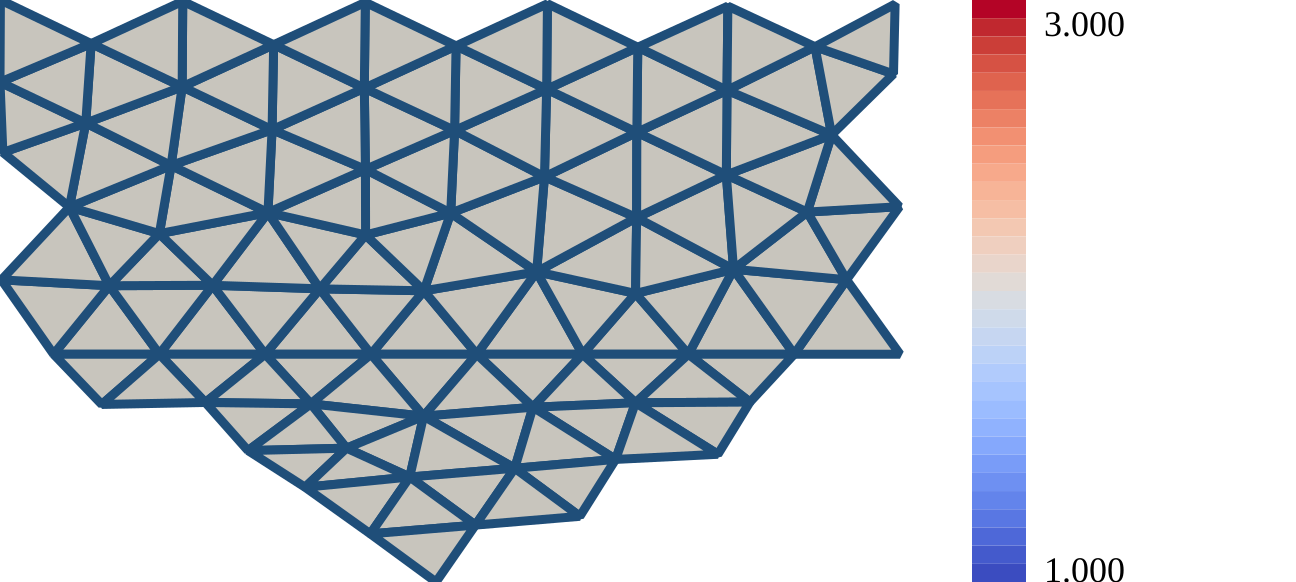

In [5]:
Mesh surfQ = attach_quality(vizCorner);
xcpp::display(render(surfQ, "quality:aspect_ratio", "coolwarm", true, 1.0, 3.0));

## Reordering / renumbering

`reorder` renumbers nodes and elements (RCM, or the Morton/Hilbert
space-filling curves) as a *pure permutation* — geometry and data pass
through untouched. `compute_bandwidth` measures the connectivity bandwidth
before and after.

In [6]:
std::int64_t before_bw = compute_bandwidth(mesh);
for (auto [method, label] : {std::pair{ReorderMethod::RCM, "rcm"}, {ReorderMethod::Morton, "morton"},
                             {ReorderMethod::Hilbert, "hilbert"}}) {
    ReorderResult rr = reorder(mesh, method);
    std::cout << std::left << std::setw(8) << label << std::right << ": bandwidth " << before_bw << " -> "
              << compute_bandwidth(rr.mMesh) << "\n";
}

rcm     : bandwidth 50857 -> 1229
morton  : bandwidth 50857 -> 41980
hilbert : bandwidth 50857 -> 46625


## Comparison (diff)

`meshes_equal` is the boolean helper for regression tests; `diff` returns a
structured report with an overall verdict. First the canonical CI pattern
— write to another format, read it back, assert equal within tolerance.

In [7]:
write_vtu("/tmp/mio_nb_surface.vtu", surface, /*binary=*/true, /*zlib=*/false);
Mesh roundtrip = registry_read("/tmp/mio_nb_surface.vtu", "vtu", {});
std::cout << "round-trip equal: " << std::boolalpha << meshes_equal(surface, roundtrip, 1e-10, 0.0) << "\n";

round-trip equal: true


Now a **localised deformation**: push a bump into the surface and let
`diff` find it.

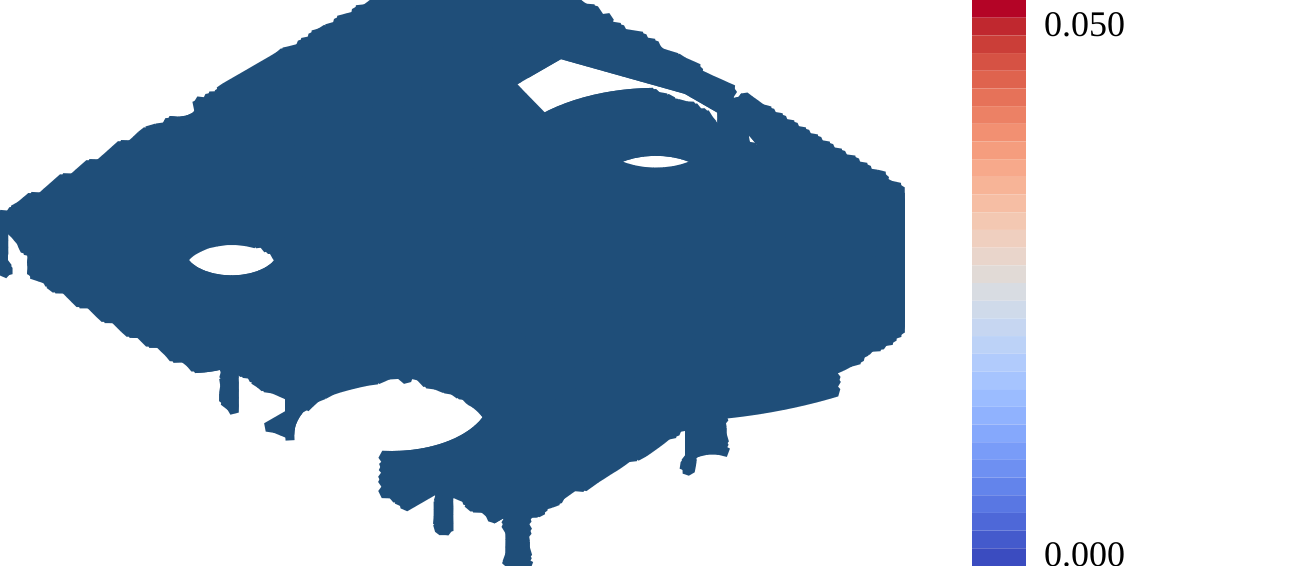

verdict          : different
points exceeding : 25843
worst point index: 36371 | max abs error: 0.0495973


In [8]:
const NDArray& base = surface.Points();
const double* bp = base.As<double>();
std::size_t np = surface.NumPoints();
double centre[3] = {0, 0, 0};
for (std::size_t i = 0; i < np; ++i)
    for (int d = 0; d < 3; ++d) centre[d] += bp[i * 3 + d] / double(np);

double maxd = 0.0;
std::vector<double> dist(np);
for (std::size_t i = 0; i < np; ++i) {
    double dx = bp[i*3]-centre[0], dy = bp[i*3+1]-centre[1], dz = bp[i*3+2]-centre[2];
    dist[i] = std::sqrt(dx*dx+dy*dy+dz*dz);
    maxd = std::max(maxd, dist[i]);
}
NDArray movedPts(DType::Float64, {np, 3});
double* mp = movedPts.As<double>();
std::copy(bp, bp + np * 3, mp);
NDArray err(DType::Float64, {np});
double* ed = err.As<double>();
for (std::size_t i = 0; i < np; ++i) {
    double t = dist[i] / (0.25 * maxd);
    double bump = 0.05 * std::exp(-(t * t));
    mp[i * 3 + 2] += bump;
    ed[i] = bump;
}
Mesh deformed = surface;
deformed.AssignPoints(std::move(movedPts));

DiffOptions dopts;
dopts.atol = 1e-6;
dopts.rtol = 0.0;
DiffReport rep = diff(surface, deformed, dopts);
std::cout << "verdict          : " << diff_verdict_name(rep.mVerdict) << "\n";
std::cout << "points exceeding : " << rep.mPoints.mNumExceeding << "\n";
std::cout << "worst point index: " << rep.mPoints.mWorstIndex << " | max abs error: " << rep.mPoints.mMaxAbsError << "\n";

// crop to a window centred on the deformation's centre, where the bump is
// actually visible (not a corner of the domain, where it would be ~0)
double bumpLo[3], bumpHi[3];
for (int d = 0; d < 3; ++d) {
    double half = 0.3 * (vizHi[d] - vizLo[d]);
    bumpLo[d] = centre[d] - half;
    bumpHi[d] = centre[d] + half;
}
Mesh vis = surface;
vis.AddPointData("abs_error", std::move(err));
Mesh visCrop = crop_bbox(vis, bumpLo, bumpHi, CropMode::All, false).mMesh;
xcpp::display(render(visCrop, "abs_error", "coolwarm", true));

`diff` also has an **unordered** mode that matches nodes by spatial
proximity, so a mesh whose nodes were merely *renumbered* still compares
equal.

In [9]:
// Shuffle the point numbering (a random permutation), remapping connectivity
// in place -- cells stay in the same order, only the node indices change.
std::size_t nshuf = surface.NumPoints();
std::vector<std::size_t> perm(nshuf);
std::iota(perm.begin(), perm.end(), 0);
std::mt19937 shufRng(0);
std::shuffle(perm.begin(), perm.end(), shufRng);   // perm[new_id] = old_id
std::vector<std::int64_t> inv(nshuf);
for (std::size_t newId = 0; newId < nshuf; ++newId) inv[perm[newId]] = std::int64_t(newId);   // old -> new

const double* origP = surface.Points().As<double>();
NDArray shufPts(DType::Float64, {nshuf, 3});
double* sp3 = shufPts.As<double>();
for (std::size_t newId = 0; newId < nshuf; ++newId)
    for (int d = 0; d < 3; ++d) sp3[newId * 3 + d] = origP[perm[newId] * 3 + d];

auto scv = surface.Cells(0);
std::size_t snc = scv.NumCells(), snpc = scv.NodesPerCell();
const std::int64_t* sconn = scv.Conn().As<std::int64_t>();
NDArray shufConn(DType::Int64, {snc, snpc});
std::int64_t* sc2 = shufConn.As<std::int64_t>();
for (std::size_t i = 0; i < snc * snpc; ++i) sc2[i] = inv[std::size_t(sconn[i])];

Mesh shuffled;
shuffled.AssignPoints(std::move(shufPts));
shuffled.AddCellBlock(scv.Type(), std::move(shufConn));

DiffReport ordered = diff(surface, shuffled, {});
DiffOptions unordered_opts; unordered_opts.unordered = true;
DiffReport unordered = diff(surface, shuffled, unordered_opts);
std::cout << "ordered   verdict: " << diff_verdict_name(ordered.mVerdict) << "\n";
std::cout << "unordered verdict: " << diff_verdict_name(unordered.mVerdict) << "\n";

ordered   verdict: different
unordered verdict: identical


## Format sniffing

In [10]:
std::cout << "sniffed format of the .vtu we wrote: " << sniff_format("/tmp/mio_nb_surface.vtu") << "\n";

sniffed format of the .vtu we wrote: vtu


## Affine transform

`transform` moves the points (translate/scale/rotate/matrix/unit-scale)
while carrying connectivity and data through. Here: a 45-degree rotation
about the x-axis, coloured by each point's *original* height.

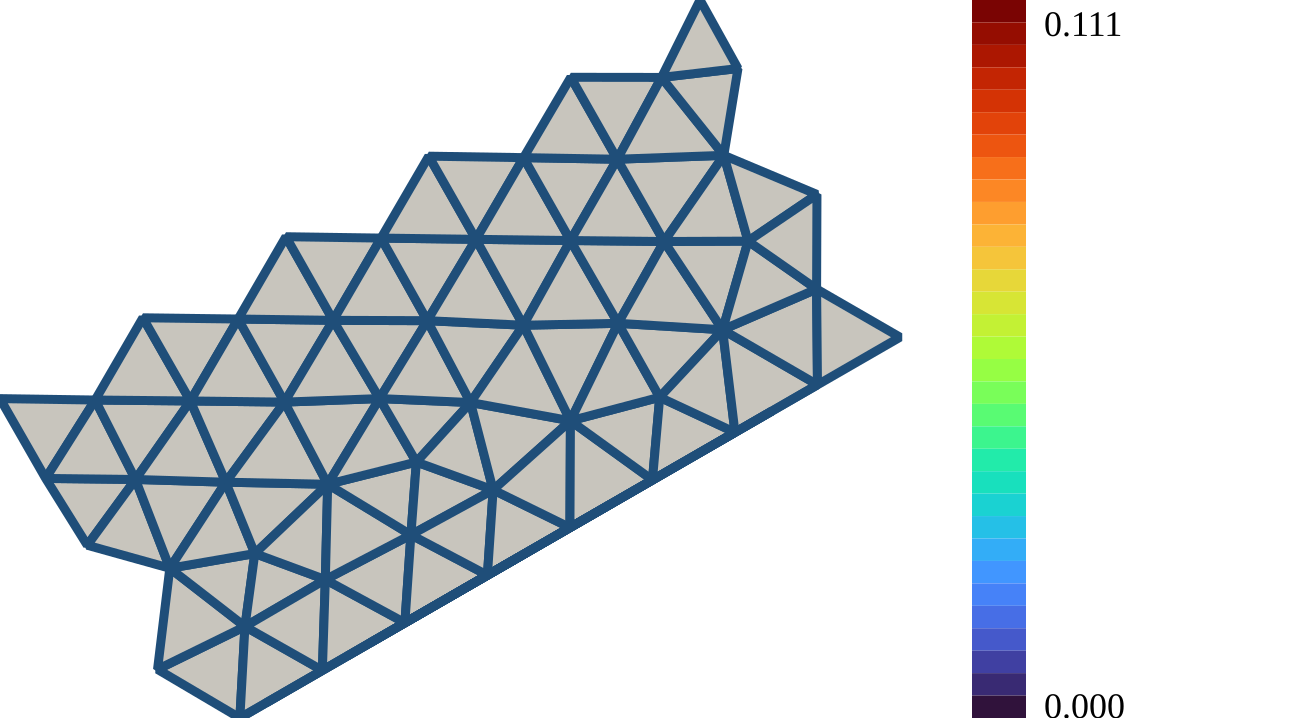

In [11]:
Mesh surfH = vizCorner;
NDArray heightArr(DType::Float64, {surfH.NumPoints()});
{
    const double* p = surfH.Points().As<double>();
    double* h = heightArr.As<double>();
    for (std::size_t i = 0; i < surfH.NumPoints(); ++i) h[i] = p[i * 3 + 2];
}
surfH.AddPointData("height", std::move(heightArr));

AffineTransform rot = transform_rotation(1, 0, 0, M_PI / 4.0);
Mesh rotated = transform(surfH, rot, /*rotate_vector_data=*/false);
xcpp::display(render(rotated, "height", "turbo", true));

## Clean (weld / prune / de-dup)

Build a deliberately messy mesh by duplicating every point and cell of the
surface, then `clean(..., weld=true)` fuses the coincident points and
drops the resulting duplicate cells.

In [12]:
std::size_t n = surface.NumPoints();
const double* sp = surface.Points().As<double>();
NDArray dupPts(DType::Float64, {2 * n, 3});
double* dp = dupPts.As<double>();
std::copy(sp, sp + n * 3, dp);
std::copy(sp, sp + n * 3, dp + n * 3);

Mesh dirty;
dirty.AssignPoints(std::move(dupPts));
auto cv = surface.Cells(0);
std::size_t nc = cv.NumCells(), npc = cv.NodesPerCell();
const std::int64_t* conn = cv.Conn().As<std::int64_t>();
NDArray dupConn(DType::Int64, {2 * nc, npc});
std::int64_t* dc = dupConn.As<std::int64_t>();
std::copy(conn, conn + nc * npc, dc);
for (std::size_t i = 0; i < nc * npc; ++i) dc[nc * npc + i] = conn[i] + std::int64_t(n);
dirty.AddCellBlock(cv.Type(), std::move(dupConn));

CleanOptions copts;
copts.weld = true;
copts.atol = 1e-8;
CleanResult cr = clean(dirty, copts);
std::cout << "points: " << dirty.NumPoints() << " -> " << cr.mMesh.NumPoints() << " (welded " << cr.mPointsWelded
          << ", duplicate cells dropped " << cr.mCellsDroppedDuplicate << ")\n";

points: 58302 -> 29151 (welded 29151, duplicate cells dropped 58394)


## Crop (bounding box / half-space)

Keep the half of the surface below the mid-plane in x.

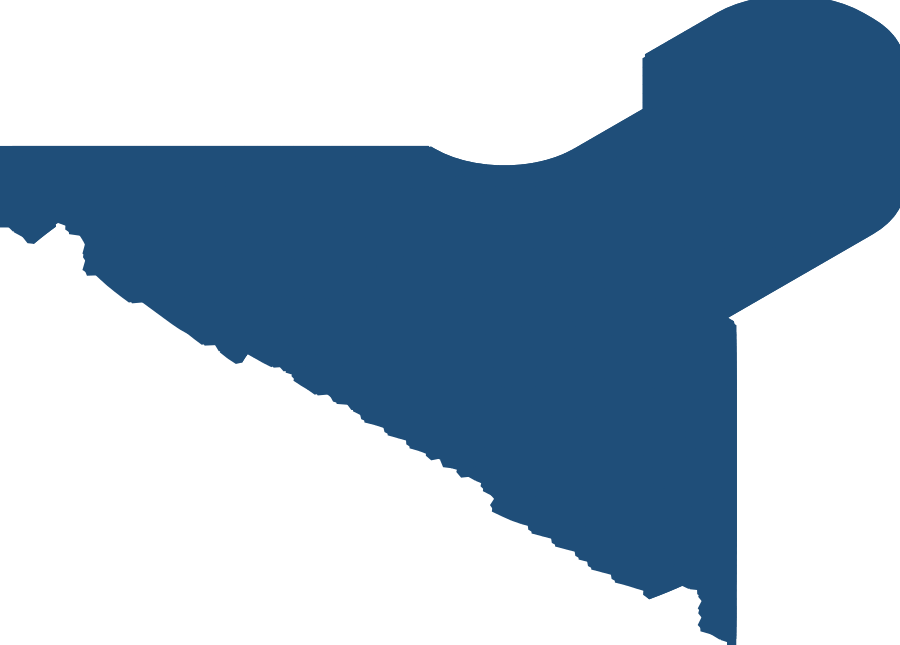

kept cells: 17122 (from 58394)


In [13]:
double lo[3], hi[3];
{
    auto s = compute_stats(surface);
    for (int d = 0; d < 3; ++d) { lo[d] = s.mBBoxMin[d]; hi[d] = s.mBBoxMax[d]; }
}
double mid[3] = {0.5 * (lo[0] + hi[0]), 0.5 * (lo[1] + hi[1]), 0.5 * (lo[2] + hi[2])};
double crop_hi[3] = {mid[0], hi[1], hi[2]};
CropResult cropped = crop_bbox(surface, lo, crop_hi, CropMode::All, false);
std::cout << "kept cells: " << cropped.mMesh.Cells(0).NumCells() << " (from " << surface.Cells(0).NumCells() << ")\n";
xcpp::display(render(cropped.mMesh));

## Merge / weld

`merge` combines several meshes. By default it concatenates; with
`weld=true` it fuses coincident points. Merging the surface with an exact
copy of itself makes the difference unmistakable: welding recovers the
original point count exactly. A second, genuinely disjoint merge — the
surface plus a shifted copy — is coloured by `source_mesh_id`
(`source_tag=true`).

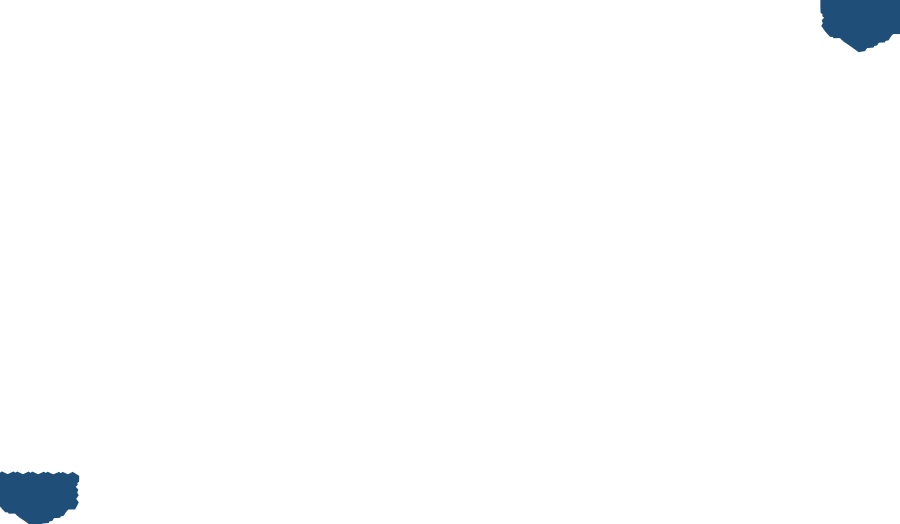

inputs       : 29151 + 29151 = 58302 points
concatenated : 58302 points
welded       : 29151 points (29151 fused)


In [14]:
Mesh surfaceCopy = surface;   // exact copy

std::vector<const Mesh*> pair_same = {&surface, &surfaceCopy};
MergeOptions plainOpts; plainOpts.source_tag = true;
MergeOptions weldOpts; weldOpts.weld = true; weldOpts.atol = 1e-8; weldOpts.source_tag = true;

MergeResult plain = merge(pair_same, plainOpts);
MergeResult welded = merge(pair_same, weldOpts);
std::cout << "inputs       : " << surface.NumPoints() << " + " << surfaceCopy.NumPoints() << " = "
          << surface.NumPoints() + surfaceCopy.NumPoints() << " points\n";
std::cout << "concatenated : " << plain.mMesh.NumPoints() << " points\n";
std::cout << "welded       : " << welded.mMesh.NumPoints() << " points ("
          << (plain.mMesh.NumPoints() - welded.mMesh.NumPoints()) << " fused)\n";

double span = hi[0] - lo[0];
AffineTransform shift = transform_translation(1.15 * span, 0.0, 0.0);
Mesh shifted = transform(surface, shift, false);

// crop each side to its own local corner before merging, purely so the
// combined figure stays a legible size (see the note on vizCorner above)
Mesh leftCorner = crop_bbox(surface, vizLo, vizCornerHi, CropMode::All, false).mMesh;
double shiftedLo[3] = {vizLo[0] + 1.15 * span, vizLo[1], vizLo[2]};
double shiftedHi[3] = {vizCornerHi[0] + 1.15 * span, vizCornerHi[1], vizCornerHi[2]};
Mesh rightCorner = crop_bbox(shifted, shiftedLo, shiftedHi, CropMode::All, false).mMesh;
std::vector<const Mesh*> pair_disjoint = {&leftCorner, &rightCorner};
MergeResult combined = merge(pair_disjoint, plainOpts);
xcpp::display(render(combined.mMesh, "source_mesh_id", "coolwarm"));

## Split (partition into pieces)

`split` partitions a mesh by type, connected component, or region. Tag
each surface cell left/right of the mid-plane and split by that region,
then recombine the pieces with `merge(source_tag=true)` to colour each
cell by its piece.

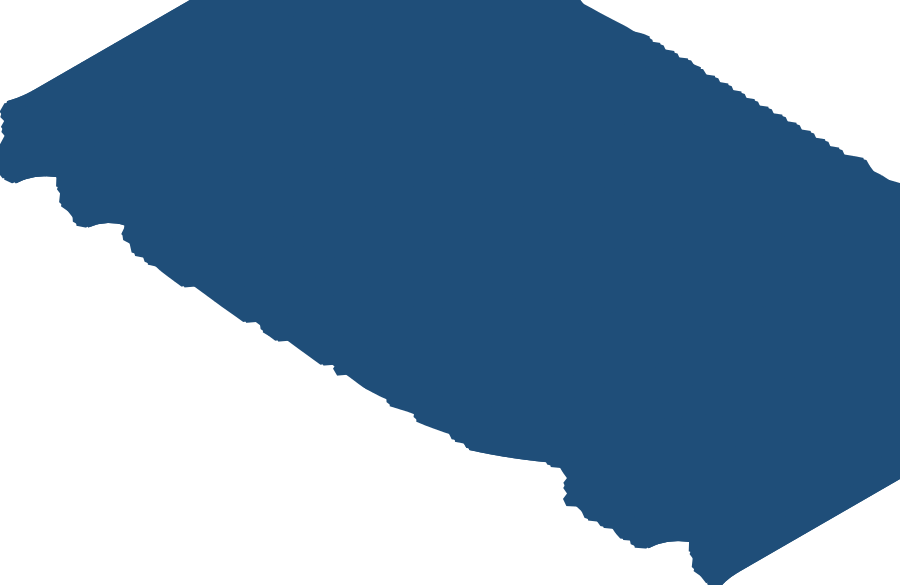

pieces: 2
  1: 41039 cells
  0: 17355 cells


In [15]:
std::size_t ncells = surface.Cells(0).NumCells();
NDArray regionArr(DType::Int64, {ncells});
{
    std::int64_t* r = regionArr.As<std::int64_t>();
    const std::int64_t* c = surface.Cells(0).Conn().As<std::int64_t>();
    std::size_t npc2 = surface.Cells(0).NodesPerCell();
    const double* p = surface.Points().As<double>();
    for (std::size_t i = 0; i < ncells; ++i) {
        double cx = 0.0;
        for (std::size_t k = 0; k < npc2; ++k) cx += p[c[i * npc2 + k] * 3 + 0] / double(npc2);
        r[i] = cx > mid[0] ? 1 : 0;
    }
}
Mesh surfR = surface;
surfR.AddCellData("region", {std::move(regionArr)});

SplitResult pieces = split(surfR, SplitBy::Tag, "region");
std::cout << "pieces: " << pieces.mPieces.size() << "\n";
for (auto& piece : pieces.mPieces) std::cout << "  " << piece.mKey << ": " << piece.mMesh.Cells(0).NumCells() << " cells\n";

std::vector<const Mesh*> pieceMeshes;
for (auto& piece : pieces.mPieces) pieceMeshes.push_back(&piece.mMesh);
MergeOptions tagOpts; tagOpts.source_tag = true;
MergeResult tagged = merge(pieceMeshes, tagOpts);

// crop to a band straddling the mid-plane, so both regions stay visible
double bandSpan = 0.2 * (hi[0] - lo[0]);
double bandLo[3] = {mid[0] - bandSpan, lo[1], lo[2]};
double bandHi[3] = {mid[0] + bandSpan, hi[1], hi[2]};
Mesh taggedBand = crop_bbox(tagged.mMesh, bandLo, bandHi, CropMode::All, false).mMesh;
xcpp::display(render(taggedBand, "source_mesh_id", "coolwarm"));

## Geometric statistics

`compute_stats` returns geometric measures — the geometric complement to
the topological cell-count summary above.

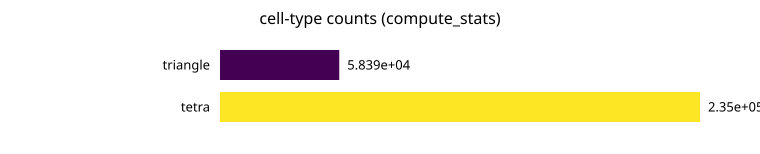

bbox     : (-3.505, -3.185, 0) -> (0, 0.625, 0.382)
centroid : (-1.34617, -1.26344, 0.138919)
area     : 41.681
volume   : signed 1.22995 | unsigned 1.22995 | inverted 0


In [16]:
StatsReport s = compute_stats(mesh);
std::cout << "bbox     : (" << s.mBBoxMin[0] << ", " << s.mBBoxMin[1] << ", " << s.mBBoxMin[2] << ") -> ("
          << s.mBBoxMax[0] << ", " << s.mBBoxMax[1] << ", " << s.mBBoxMax[2] << ")\n";
std::cout << "centroid : (" << s.mCentroid[0] << ", " << s.mCentroid[1] << ", " << s.mCentroid[2] << ")\n";
std::cout << "area     : " << s.mTotalArea << "\n";
std::cout << "volume   : signed " << s.mSignedVolume << " | unsigned " << s.mUnsignedVolume
          << " | inverted " << s.mNumInverted << "\n";

std::vector<std::string> typeNames;
std::vector<double> typeCounts;
for (auto& [name, count] : s.mCellTypeCounts) { typeNames.push_back(name); typeCounts.push_back(double(count)); }
xcpp::display(bar_chart(typeNames, typeCounts, "cell-type counts (compute_stats)"));

## Cell conversion (linearize / simplexify / elevate)

`convert_cells` rewrites which cell *types* a mesh is built from. Take a
small hexahedral block and **simplexify** it: each hexahedron becomes 6
tetrahedra reusing the parent's own corner nodes, so no points are added
and the volume is conserved exactly.

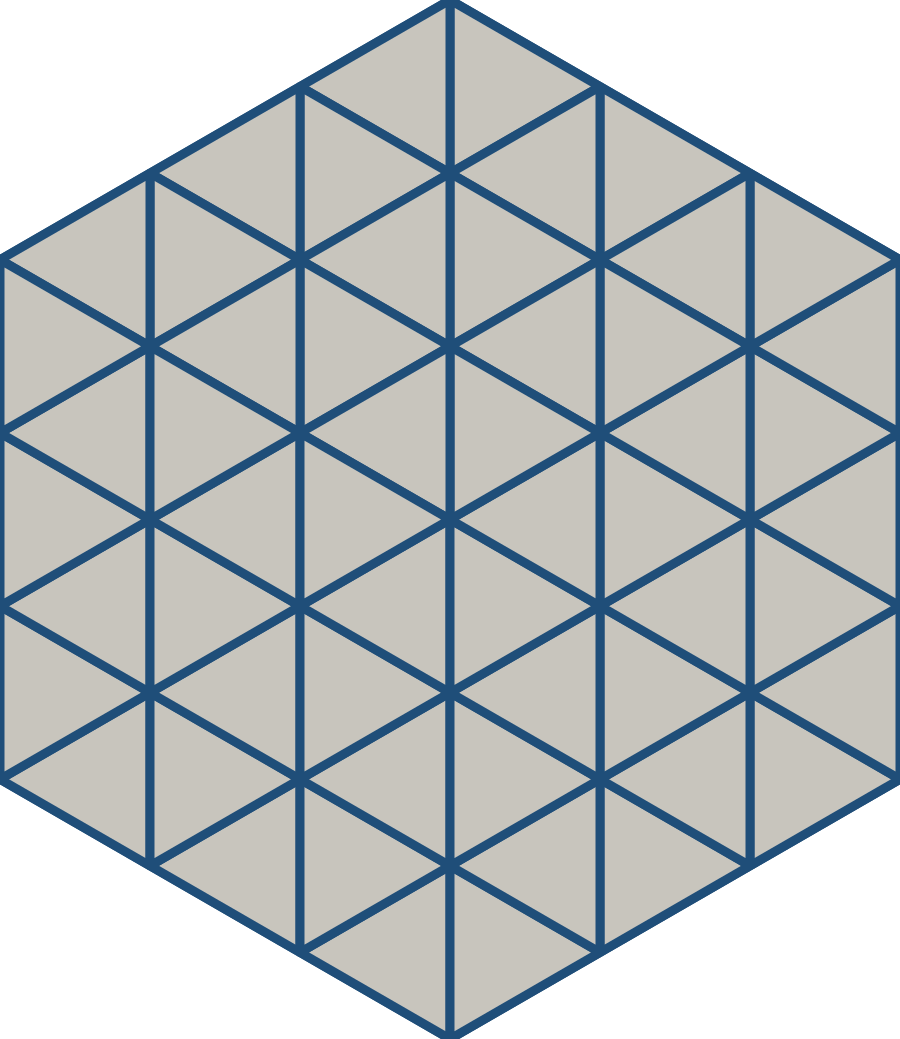

before: 27 hexahedron | points 64 | volume 27
after : 162 tetra | points 64 | volume 27
inverted cells after simplexify: 0


In [17]:
Mesh hexes = hex_block(3);
ConvertCellsOptions ccopts;
ccopts.mMode = ConvertCellsMode::Simplexify;
ConvertCellsResult simplexified = convert_cells(hexes, ccopts);

StatsReport before = compute_stats(hexes), after = compute_stats(simplexified.mMesh);
std::cout << "before: " << before.mNumCells << " " << hexes.Cells(0).Type() << " | points " << hexes.NumPoints()
          << " | volume " << before.mUnsignedVolume << "\n";
std::cout << "after : " << after.mNumCells << " " << simplexified.mMesh.Cells(0).Type() << " | points "
          << simplexified.mMesh.NumPoints() << " | volume " << after.mUnsignedVolume << "\n";
std::cout << "inverted cells after simplexify: " << after.mNumInverted << "\n";
xcpp::display(render(simplexified.mMesh));

In [18]:
// elevate does the opposite: linear cells gain a node per unique edge.
ConvertCellsOptions elOpts; elOpts.mMode = ConvertCellsMode::Elevate;
ConvertCellsResult elevated = convert_cells(hexes, elOpts);
std::cout << "elevate    : " << hexes.Cells(0).Type() << " -> " << elevated.mMesh.Cells(0).Type()
          << " | points " << hexes.NumPoints() << " -> " << elevated.mMesh.NumPoints() << "\n";

ConvertCellsOptions linOpts; linOpts.mMode = ConvertCellsMode::Linearize;
ConvertCellsResult back = convert_cells(elevated.mMesh, linOpts);
std::cout << "linearize  : " << elevated.mMesh.Cells(0).Type() << " -> " << back.mMesh.Cells(0).Type()
          << " | points " << elevated.mMesh.NumPoints() << " -> " << back.mMesh.NumPoints() << "\n";
std::cout << "round-trip recovers the original mesh: " << std::boolalpha << meshes_equal(hexes, back.mMesh) << "\n";

elevate    : hexahedron -> hexahedron20 | points 64 -> 208
linearize  : hexahedron20 -> hexahedron | points 208 -> 64
round-trip recovers the original mesh: true


## Uniform refinement

`refine` subdivides every cell into congruent children of the **same**
type, inserting shared nodes at the midpoints of edges, quad faces and
(hexahedron only) the body — no hanging nodes.

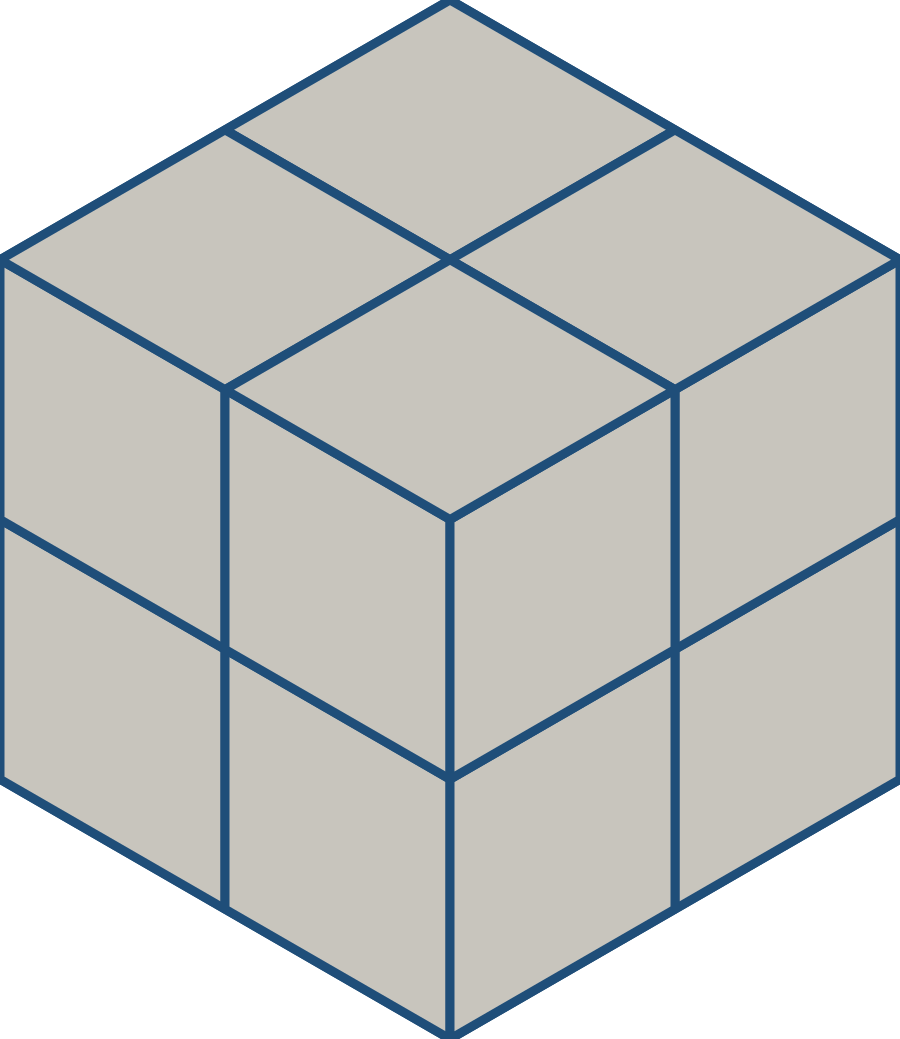

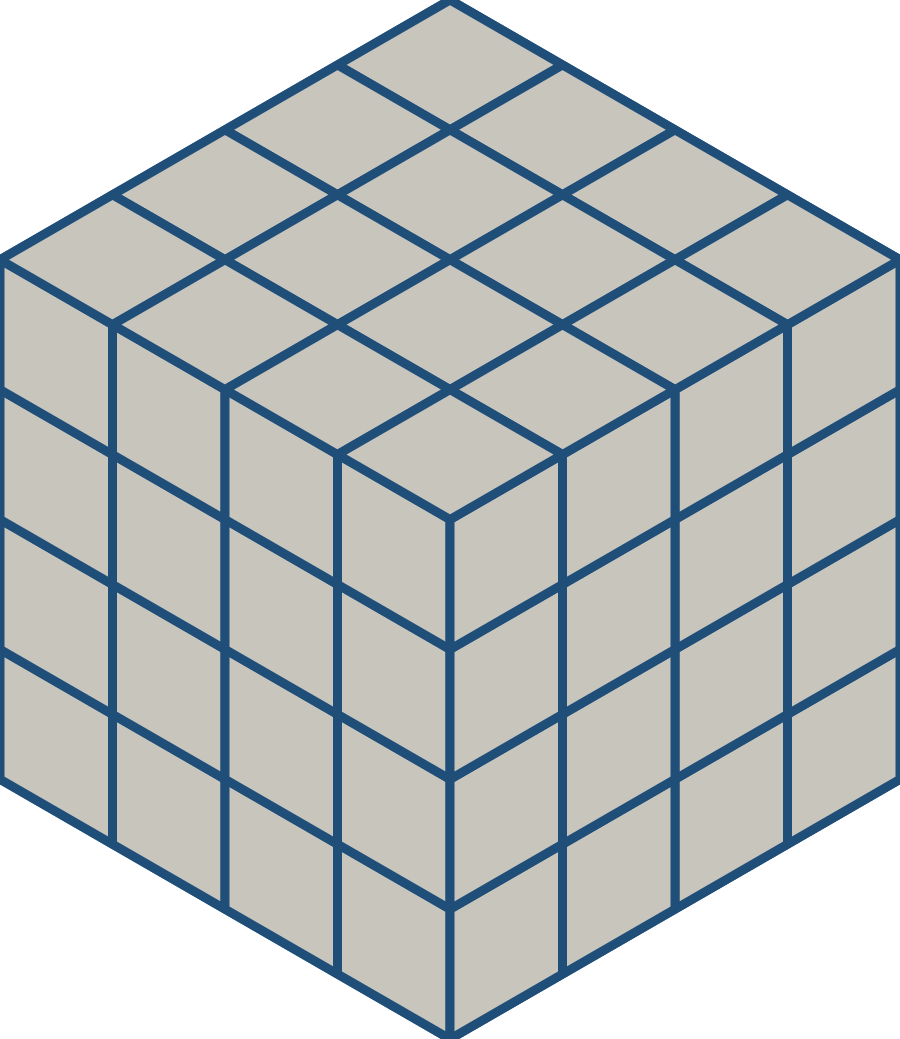

coarse: 8 cells | 27 points | volume 8
fine  : 64 cells | 125 points | volume 8
points: 125 (a conforming 5x5x5 lattice = 125) vs 216 if every cell kept its own copy
max interpolation error on a linear field: 0


In [19]:
Mesh coarse = hex_block(2);
NDArray heightField(DType::Float64, {coarse.NumPoints()});
{
    const double* p = coarse.Points().As<double>();
    double* h = heightField.As<double>();
    for (std::size_t i = 0; i < coarse.NumPoints(); ++i) h[i] = p[i * 3 + 2];
}
coarse.AddPointData("height", std::move(heightField));

RefineResult fine = refine(coarse, {});
StatsReport coarseStats = compute_stats(coarse), fineStats = compute_stats(fine.mMesh);
std::cout << "coarse: " << coarseStats.mNumCells << " cells | " << coarse.NumPoints() << " points | volume "
          << coarseStats.mUnsignedVolume << "\n";
std::cout << "fine  : " << fineStats.mNumCells << " cells | " << fine.mMesh.NumPoints() << " points | volume "
          << fineStats.mUnsignedVolume << "\n";
std::cout << "points: " << fine.mMesh.NumPoints() << " (a conforming 5x5x5 lattice = 125) vs "
          << (coarse.Cells(0).NumCells() * 27) << " if every cell kept its own copy\n";

const double* fh = fine.mMesh.PointData("height").As<double>();
const double* fp = fine.mMesh.Points().As<double>();
double refineErr = 0.0;
for (std::size_t i = 0; i < fine.mMesh.NumPoints(); ++i) refineErr = std::max(refineErr, std::abs(fh[i] - fp[i * 3 + 2]));
std::cout << "max interpolation error on a linear field: " << refineErr << "\n";

xcpp::display(render(coarse));
xcpp::display(render(fine.mMesh));

## Selective (adaptive) refinement

The same call refines a **subset** and closes the mesh back up, so the result is
still conforming. Give it global (block-major) cell indices, a region name, or a
threshold on a `cell_data` array.

An affected neighbour is promoted to the smallest split its cell type admits, not
to a full one — for a hexahedron that means the refinement travels through one
*dual sheet* rather than the whole block. `RefineClosure::Propagate` is the
honest alternative: always conforming for every cell type, but a fully split cell
splits all of its edges, so on a connected mesh it *is* the uniform refinement.

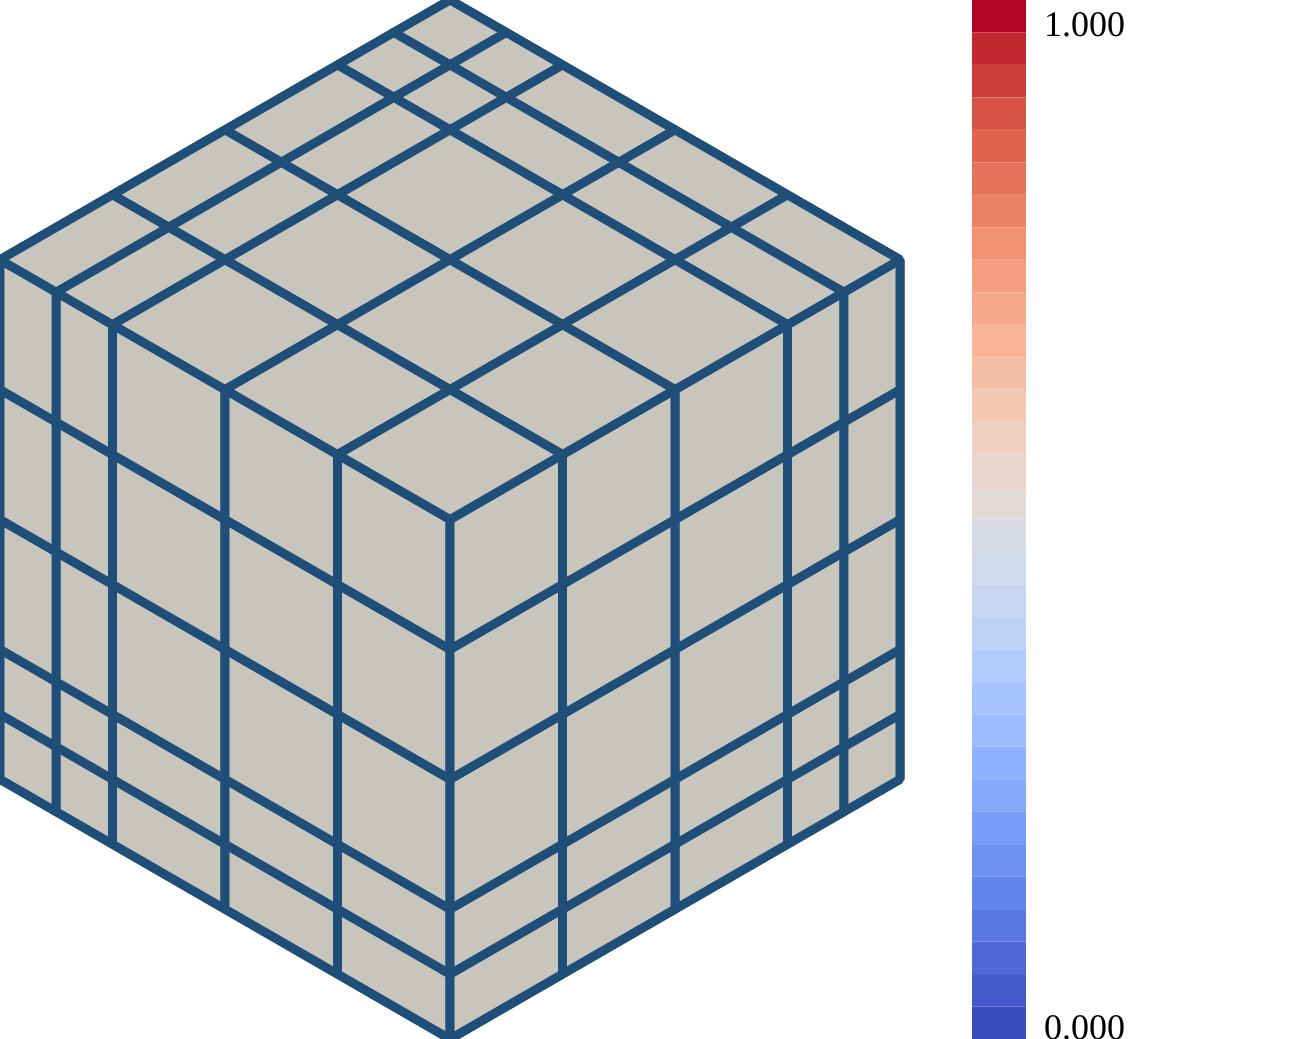

     input: 64 cells
  redgreen: 125 cells
 propagate: 512 cells
   uniform: 512 cells
volume  in 64  out 64


In [20]:
// Every name here is `adapt_`-prefixed on purpose: cells share one persistent
// global namespace, so a bare `n` or `pts` would collide with an earlier cell.
Mesh adapt_block = hex_block(4);

RefineOptions adapt_graded_opts;
adapt_graded_opts.mCells = {0};            // one corner hexahedron
adapt_graded_opts.mRecordLevels = true;
RefineResult adapt_graded = refine(adapt_block, adapt_graded_opts);

RefineOptions adapt_flood_opts;
adapt_flood_opts.mCells = {0};
adapt_flood_opts.mClosure = RefineClosure::Propagate;
RefineResult adapt_flooded = refine(adapt_block, adapt_flood_opts);

std::cout << "     input: " << compute_stats(adapt_block).mNumCells << " cells\n";
std::cout << "  redgreen: " << compute_stats(adapt_graded.mMesh).mNumCells << " cells\n";
std::cout << " propagate: " << compute_stats(adapt_flooded.mMesh).mNumCells << " cells\n";
std::cout << "   uniform: " << compute_stats(refine(adapt_block, {}).mMesh).mNumCells << " cells\n";

// Refinement changes resolution, not the object.
std::cout << "volume  in " << compute_stats(adapt_block).mUnsignedVolume
          << "  out " << compute_stats(adapt_graded.mMesh).mUnsignedVolume << "\n";

// refine:level is the grading: +1 per full split, and a transitional cell keeps
// its parent's level because a closure is not a refinement.
xcpp::display(render(adapt_graded.mMesh, "refine:level", "coolwarm", true));


## Decimation (QEM edge collapse)

`decimate` is `refine`'s inverse: it *reduces* a surface mesh's face count by
greedy quadric-error-metric (Garland–Heckbert) edge collapse. Boundary and
feature vertices are pinned by default (so the cropped corner keeps its
outline and creases), and the link condition plus a normal-flip guard reject
anything that would change topology or fold the surface. Volume meshes are
refused by name — extract the skin first, then decimate it.

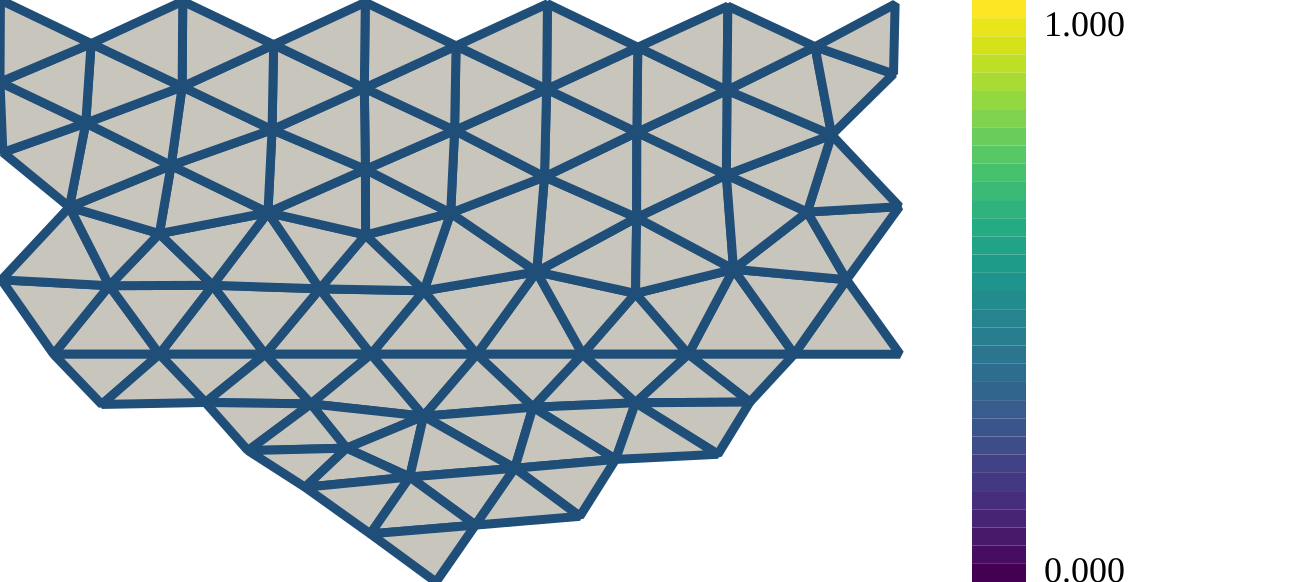

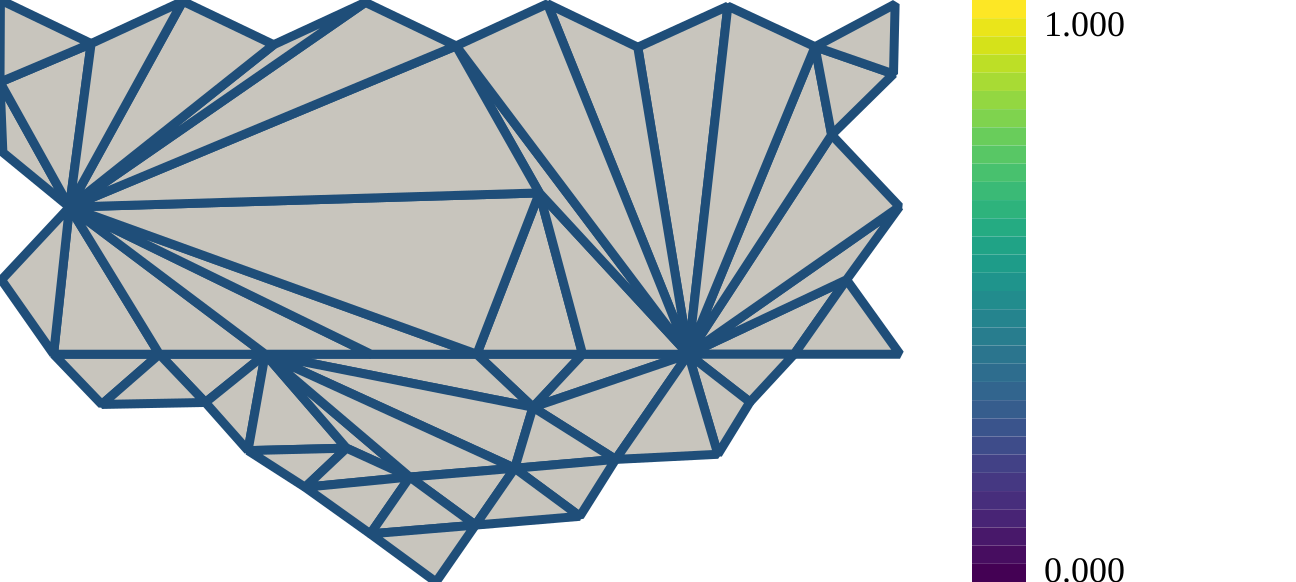

corner : 107 triangles | 71 points
coarse : 53 triangles | 44 points
removed 54 faces, rejected 34 collapses, max quadric error 0
total area: 0.0407135 -> 0.0407135


In [21]:
// Decimate the cropped surface corner to half of its triangles, then render
// both sides coloured by element quality: the collapse leaves well-shaped
// triangles at half the resolution, and the outline/creases stay put.
DecimateOptions decOpts;
decOpts.mTargetRatio = 0.5;
DecimateResult decRes = decimate(vizCorner, decOpts);

std::size_t decFacesIn = 0, decFacesOut = 0;
for (std::size_t b = 0; b < vizCorner.NumCellBlocks(); ++b) decFacesIn += vizCorner.Cells(b).NumCells();
for (std::size_t b = 0; b < decRes.mMesh.NumCellBlocks(); ++b) decFacesOut += decRes.mMesh.Cells(b).NumCells();
std::cout << "corner : " << decFacesIn << " triangles | " << vizCorner.NumPoints() << " points\n";
std::cout << "coarse : " << decFacesOut << " triangles | " << decRes.mMesh.NumPoints() << " points\n";
std::cout << "removed " << decRes.mFacesRemoved << " faces, rejected " << decRes.mCollapsesRejected
          << " collapses, max quadric error " << decRes.mMaxErrorApplied << "\n";
std::cout << "total area: " << compute_stats(vizCorner).mTotalArea << " -> "
          << compute_stats(decRes.mMesh).mTotalArea << "\n";

Mesh decQBefore = attach_quality(vizCorner);
Mesh decQAfter = attach_quality(decRes.mMesh);
xcpp::display(render(decQBefore, "quality:scaled_jacobian", "viridis", true, 0.0, 1.0));
xcpp::display(render(decQAfter, "quality:scaled_jacobian", "viridis", true, 0.0, 1.0));

## Partitioning (N balanced parts)

`partition` decomposes a mesh into exactly N balanced pieces — the
count-driven complement to the criterion-driven `split`. `method=SFC`
(pinned here for determinism) orders cells along a Hilbert curve of their
centroids and cuts it into contiguous ranges.

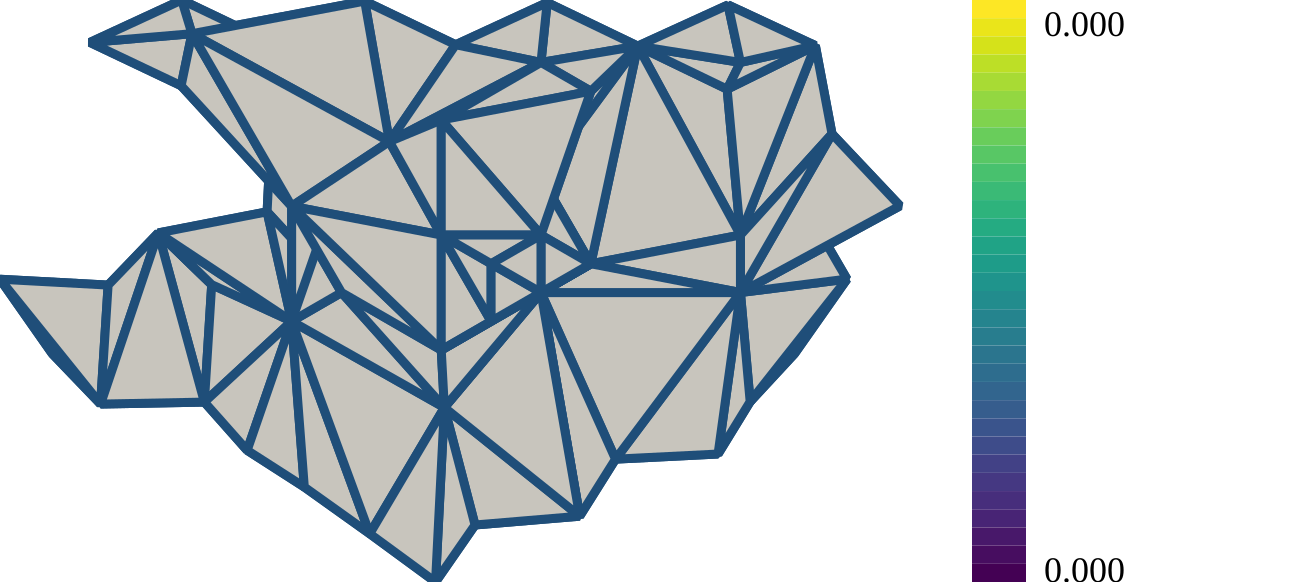

part sizes: [48902 48901 48901 48902 48901 48901 ] (max-min = 1 cells)
piece cell counts: 48902 48901 48901 48902 48901 48901 


In [22]:
PartitionOptions popts;
popts.mNParts = 6;
popts.mMethod = PartitionMethod::SFC;

auto labels = partition_labels(mesh, popts);
std::vector<std::int64_t> sizes(6, 0);
for (auto& block : labels) {
    const std::int64_t* d = block.As<std::int64_t>();
    for (std::size_t i = 0; i < block.Size(); ++i) sizes[std::size_t(d[i])]++;
}
std::int64_t partMin = *std::min_element(sizes.begin(), sizes.end());
std::int64_t partMax = *std::max_element(sizes.begin(), sizes.end());
std::cout << "part sizes: [";
for (auto v : sizes) std::cout << v << " ";
std::cout << "] (max-min = " << (partMax - partMin) << " cells)\n";

// AddCellData takes one array per block -- build them from `labels` (already block-aligned).
Mesh labelled = mesh;
std::vector<NDArray> labelBlocks;
for (auto& block : labels) { NDArray b(DType::Int64, block.Shape()); std::copy(block.As<std::int64_t>(), block.As<std::int64_t>() + block.Size(), b.As<std::int64_t>()); labelBlocks.push_back(std::move(b)); }
labelled.AddCellData("partition:part", std::move(labelBlocks));

// crop for the figure -- `mesh` is the ~293k-cell volume mesh, several times
// larger than the surface figures above
Mesh labelledCorner = crop_bbox(labelled, vizLo, vizCornerHi, CropMode::All, false).mMesh;
xcpp::display(render(labelledCorner, "partition:part", "viridis", true));

PartitionResult partitionPieces = partition(mesh, popts);
std::cout << "piece cell counts: ";
for (auto& piece : partitionPieces.mPieces) {
    std::size_t c = 0;
    for (std::size_t i = 0; i < piece.mMesh.NumCellBlocks(); ++i) c += piece.mMesh.Cells(i).NumCells();
    std::cout << c << " ";
}
std::cout << "\n";

## Smoothing (Laplacian / Taubin)

`smooth` relaxes each free node toward the centroid of its edge
neighbours. **Laplacian** shrinks the mesh (unconditionally low-pass);
**Taubin** (the default) follows every `+lambda` pass with a larger
`-mu` pass, giving the pair a pass band that leaves the volume
essentially intact. Below: a jittered hex block, several cells tangled,
coloured by scaled Jacobian before and after (1.0 = perfect cube,
negative = inverted).

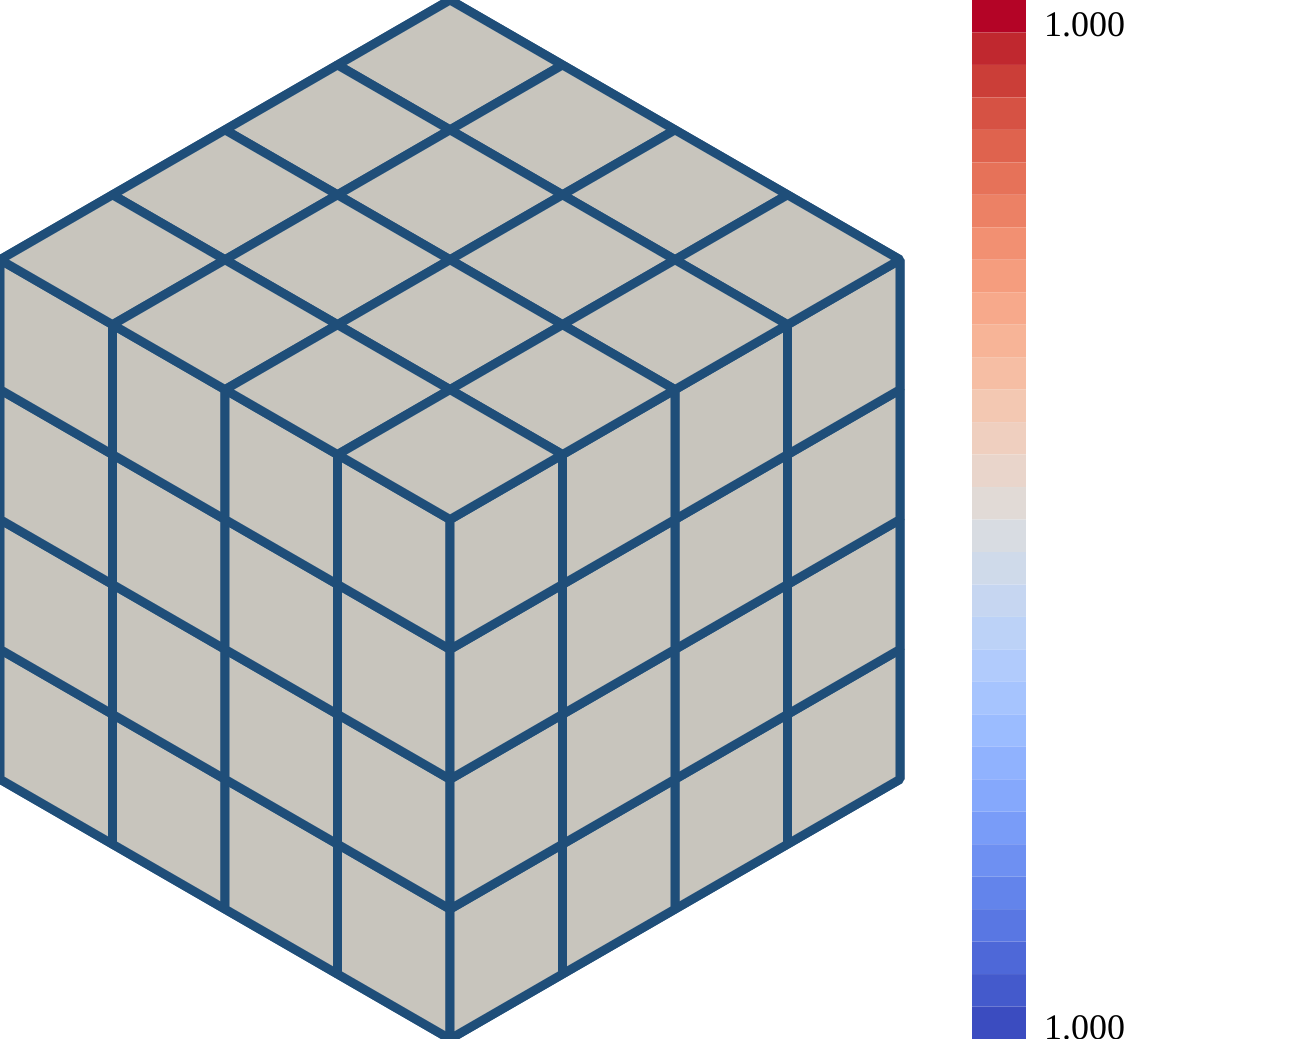

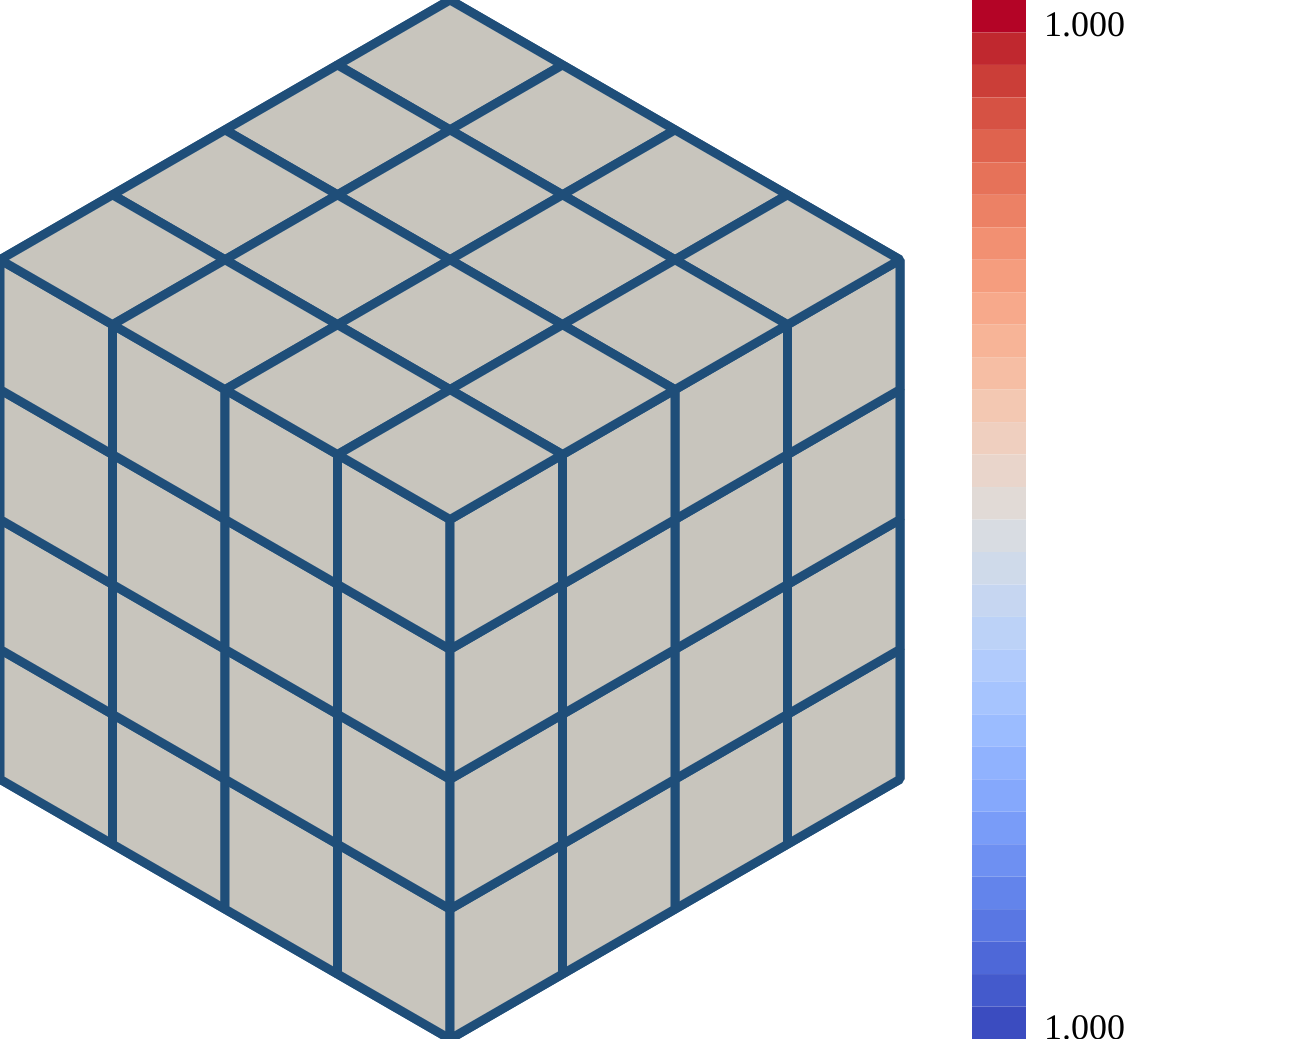

points 125 -> 125   cells 64 -> 64 (unchanged: smooth only moves nodes)
min scaled Jacobian : -0.854381 -> 0.852823
inverted cells      : 0 -> 0
volume              : 64 -> 64 (the exact block is 64)
nodes moved: 27, max displacement: 0.993898, skipped by the inversion guard: 0


In [23]:
Mesh rough = hex_block(4);
{
    NDArray pcopy(DType::Float64, rough.Points().Shape());
    std::copy(rough.Points().As<double>(), rough.Points().As<double>() + rough.Points().Size(), pcopy.As<double>());
    double* p = pcopy.As<double>();
    std::mt19937 rng(3);
    std::normal_distribution<double> jitter(0.0, 0.35);
    for (std::size_t i = 0; i < rough.NumPoints(); ++i) {
        bool interior = true;
        for (int d = 0; d < 3; ++d) if (!(p[i*3+d] > 0.0 && p[i*3+d] < 4.0)) interior = false;
        if (interior) for (int d = 0; d < 3; ++d) p[i * 3 + d] += jitter(rng);
    }
    rough.AssignPoints(std::move(pcopy));
}

SmoothOptions sopts;
sopts.mIterations = 20;
SmoothResult relaxed = smooth(rough, sopts);

QualityReport q0 = compute_quality(rough), q1 = compute_quality(relaxed.mMesh);
StatsReport s0 = compute_stats(rough), s1 = compute_stats(relaxed.mMesh);
auto find_metric = [](const QualityReport& r, const std::string& n) -> const QualityMetricSummary& {
    for (auto& [name, s] : r.mMetrics) if (name == n) return s;
    throw std::runtime_error("metric not found");
};
std::cout << "points " << rough.NumPoints() << " -> " << relaxed.mMesh.NumPoints() << "   cells "
          << s0.mNumCells << " -> " << s1.mNumCells << " (unchanged: smooth only moves nodes)\n";
std::cout << "min scaled Jacobian : " << find_metric(q0, "quality:scaled_jacobian").mMin << " -> "
          << find_metric(q1, "quality:scaled_jacobian").mMin << "\n";
std::cout << "inverted cells      : " << s0.mNumInverted << " -> " << s1.mNumInverted << "\n";
std::cout << "volume              : " << s0.mUnsignedVolume << " -> " << s1.mUnsignedVolume << " (the exact block is 64)\n";
std::cout << "nodes moved: " << relaxed.mNumNodesMoved << ", max displacement: " << relaxed.mMaxDisplacement
          << ", skipped by the inversion guard: " << relaxed.mNumSkippedInversion << "\n";

xcpp::display(render(attach_quality(extract_surface(rough)), "quality:aspect_ratio", "coolwarm", true));
xcpp::display(render(attach_quality(extract_surface(relaxed.mMesh)), "quality:aspect_ratio", "coolwarm", true));

## Field interpolation (cross-mesh transfer)

`interpolate(source, target)` is the first **two-mesh** operation that
moves *data*: a copy of the target with the source's arrays sampled onto
it. `method=Barycentric` simplexifies the source and interpolates
linearly — exact on a linear field.

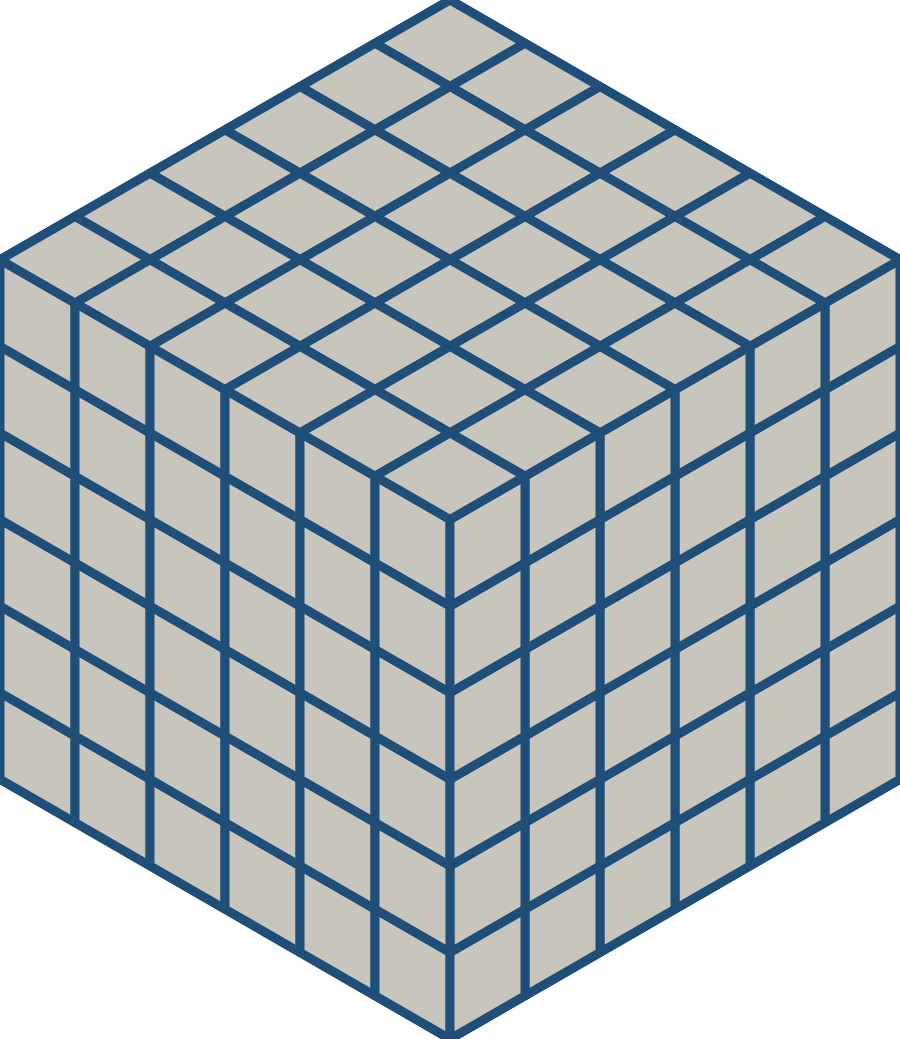

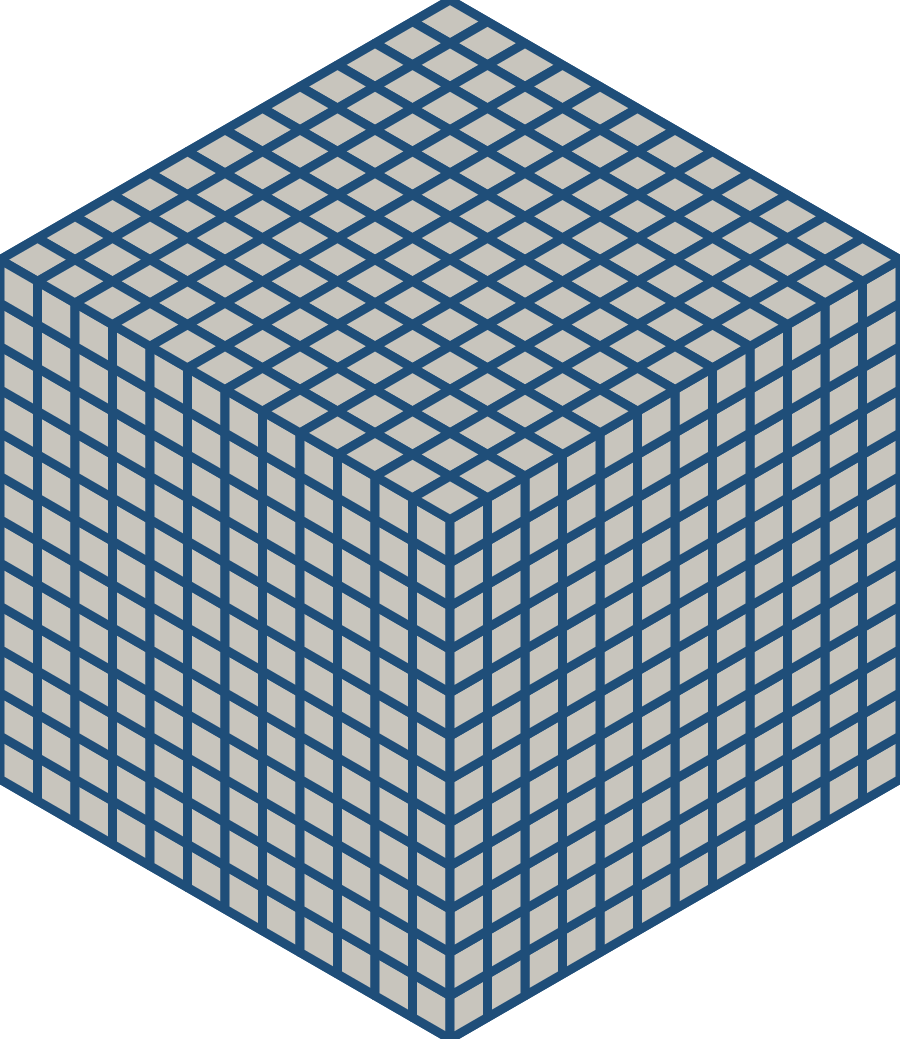

transferred 'f' from 343 onto 15625 points
max |error| on a linear field: 3.55271e-15


In [24]:
Mesh interpCoarse = hex_block(6, 1.0 / 6.0);
{
    NDArray f(DType::Float64, {interpCoarse.NumPoints()});
    const double* p = interpCoarse.Points().As<double>();
    double* fd = f.As<double>();
    for (std::size_t i = 0; i < interpCoarse.NumPoints(); ++i)
        fd[i] = std::sin(4.0 * p[i * 3]) * std::cos(4.0 * p[i * 3 + 1]) + p[i * 3 + 2];
    interpCoarse.AddPointData("f", std::move(f));
}
Mesh interpFine = hex_block(24, 1.0 / 24.0);

InterpolateOptions iopts;
iopts.mMethod = InterpolateMethod::Barycentric;
Mesh mapped = interpolate(interpCoarse, interpFine, iopts);
std::cout << "transferred 'f' from " << interpCoarse.NumPoints() << " onto " << mapped.NumPoints() << " points\n";

// linear-exact check
NDArray lin(DType::Float64, {interpCoarse.NumPoints()});
{
    const double* p = interpCoarse.Points().As<double>();
    double* ld = lin.As<double>();
    for (std::size_t i = 0; i < interpCoarse.NumPoints(); ++i) ld[i] = 2*p[i*3]+3*p[i*3+1]+5*p[i*3+2];
}
interpCoarse.AddPointData("lin", std::move(lin));
InterpolateOptions linOpts2; linOpts2.mMethod = InterpolateMethod::Barycentric; linOpts2.mArrays = {"lin"};
Mesh linMapped = interpolate(interpCoarse, interpFine, linOpts2);
const double* mlin = linMapped.PointData("lin").As<double>();
const double* mp2 = linMapped.Points().As<double>();
double maxErr = 0.0;
for (std::size_t i = 0; i < linMapped.NumPoints(); ++i)
    maxErr = std::max(maxErr, std::abs(mlin[i] - (2*mp2[i*3]+3*mp2[i*3+1]+5*mp2[i*3+2])));
std::cout << "max |error| on a linear field: " << maxErr << "\n";

// crop the fine target to an eighth of the domain for the figure -- 13824
// cells makes for an oversized SVG, per the note on vizCorner above
double fineLo[3] = {0.0, 0.0, 0.0}, fineHi[3] = {0.5, 0.5, 0.5};
Mesh mappedCorner = crop_bbox(mapped, fineLo, fineHi, CropMode::All, false).mMesh;
xcpp::display(render(interpCoarse, "f", "viridis"));
xcpp::display(render(mappedCorner, "f", "viridis"));

## Conservative interpolation (mass-preserving field transfer)

`conservative_interpolate(source, target)` is the mass-preserving sibling of
`interpolate`: over the region the two meshes share, `sum(target value *
target measure)` equals `sum(source value * source measure)` exactly, a
property `interpolate`'s pointwise sampling does not have. Demonstrated below
on `cell_data` -- the exact path (`point_data` goes through a documented
lumped approximation instead).


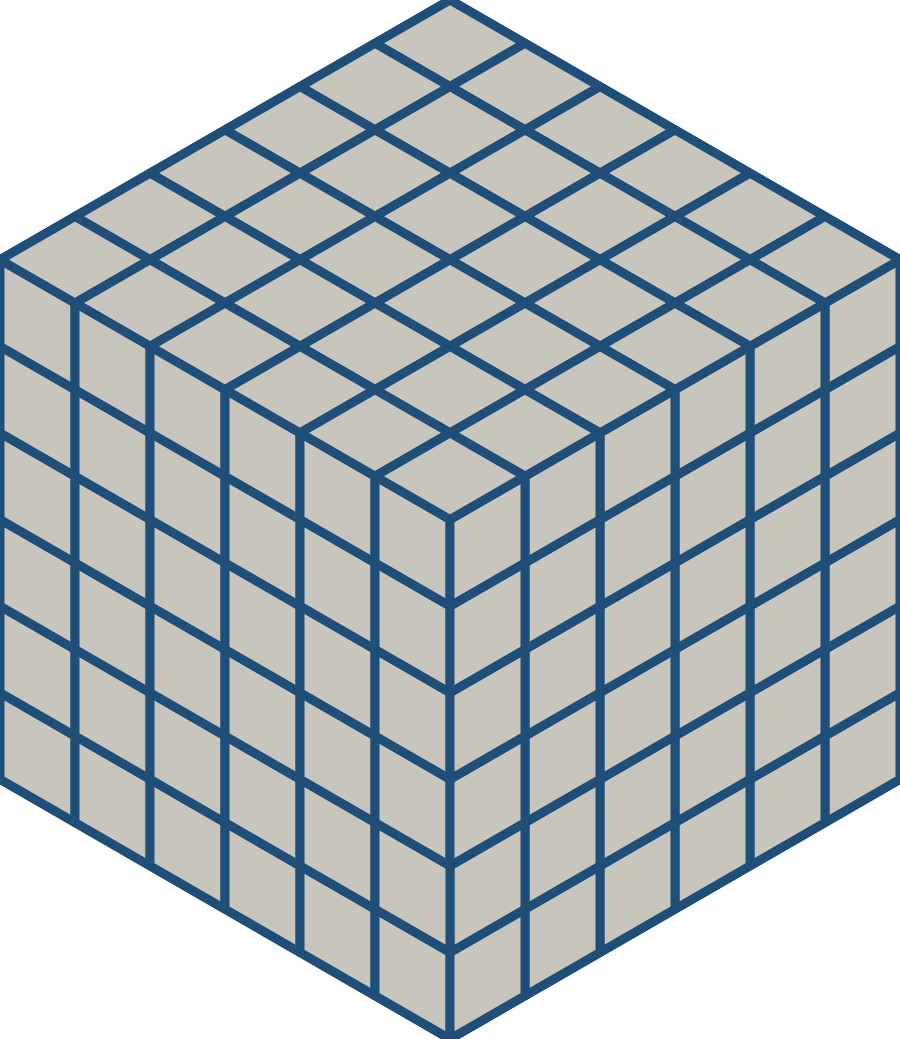

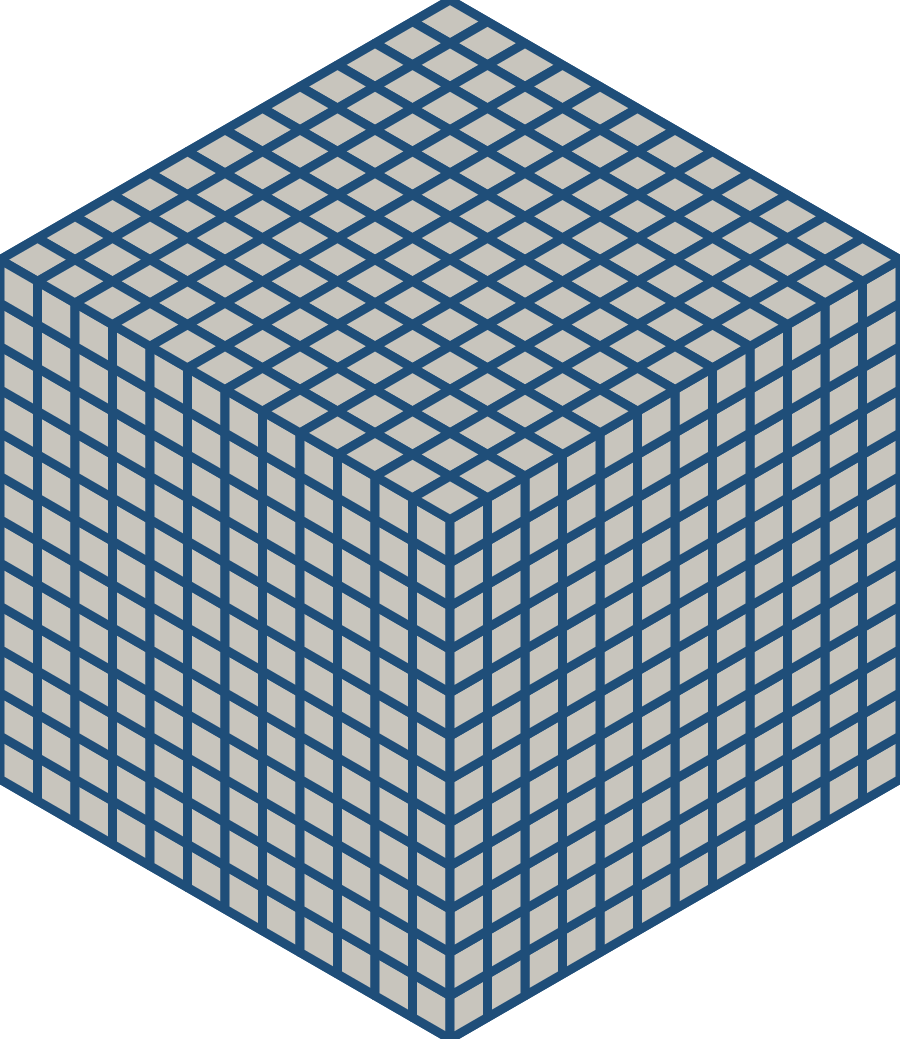

source integral: 0.41882
target integral: 0.41882 (conserved exactly)


In [25]:
Mesh consCoarse = hex_block(6, 1.0 / 6.0);
{
    const Mesh::CellView cb = *consCoarse.CellRange().begin();
    NDArray p(DType::Float64, {cb.NumCells()});
    const double* pts = consCoarse.Points().As<double>();
    const std::int64_t* conn = cb.Conn().As<std::int64_t>();
    double* pd = p.As<double>();
    for (std::size_t c = 0; c < cb.NumCells(); ++c) {
        double cx = 0.0, cy = 0.0, cz = 0.0;
        for (std::size_t k = 0; k < 8; ++k) {
            std::int64_t n = conn[c * 8 + k];
            cx += pts[n * 3 + 0];
            cy += pts[n * 3 + 1];
            cz += pts[n * 3 + 2];
        }
        cx /= 8.0; cy /= 8.0; cz /= 8.0;
        pd[c] = std::sin(4.0 * cx) * std::cos(4.0 * cy) + cz;
    }
    std::vector<NDArray> blocks;
    blocks.push_back(std::move(p));
    consCoarse.AddCellData("p", std::move(blocks));
}
Mesh consFine = hex_block(24, 1.0 / 24.0);

ConservativeInterpolateOptions consOpts;
consOpts.mArrays = {"p"};
Mesh consMapped = conservative_interpolate(consCoarse, consFine, consOpts);

// Both are uniform grids of known cell volume, so the conserved integral is
// exactly sum(value) * cell_volume.
auto sumCellData = [](const Mesh& m, const std::string& name) {
    const NDArray& d = m.CellData(name, 0);
    const double* v = d.As<double>();
    double total = 0.0;
    for (std::size_t i = 0; i < d.Shape()[0]; ++i) total += v[i];
    return total;
};
double srcIntegral = sumCellData(consCoarse, "p") * std::pow(1.0 / 6.0, 3);
double tgtIntegral = sumCellData(consMapped, "p") * std::pow(1.0 / 24.0, 3);
std::cout << "source integral: " << srcIntegral << "\n";
std::cout << "target integral: " << tgtIntegral << " (conserved exactly)\n";

// crop the fine target to an eighth of the domain for the figure, matching
// the interpolate demo above (13824 cells makes for an oversized SVG).
double consFineLo[3] = {0.0, 0.0, 0.0}, consFineHi[3] = {0.5, 0.5, 0.5};
Mesh consMappedCorner = crop_bbox(consMapped, consFineLo, consFineHi, CropMode::All, false).mMesh;
xcpp::display(render(consCoarse, "p", "viridis"));
xcpp::display(render(consMappedCorner, "p", "viridis"));


## Cross-section (slice)

`slice` computes the planar **cross-section** of a mesh — the intersection with a plane, one topological dimension below the cut cells (a volume mesh &rarr; a `triangle`/`quad` surface). The input is simplexified first (marching tetrahedra), cut points on shared edges are deduped (watertight), and `point_data` is interpolated at the cut. Unlike `crop`, which keeps whole cells on one side, `slice` computes the intersection and lowers the dimension. Below, a unit cube of hexahedra carrying an analytic field `f` is cut by its mid-plane; `f` rides through onto the section.

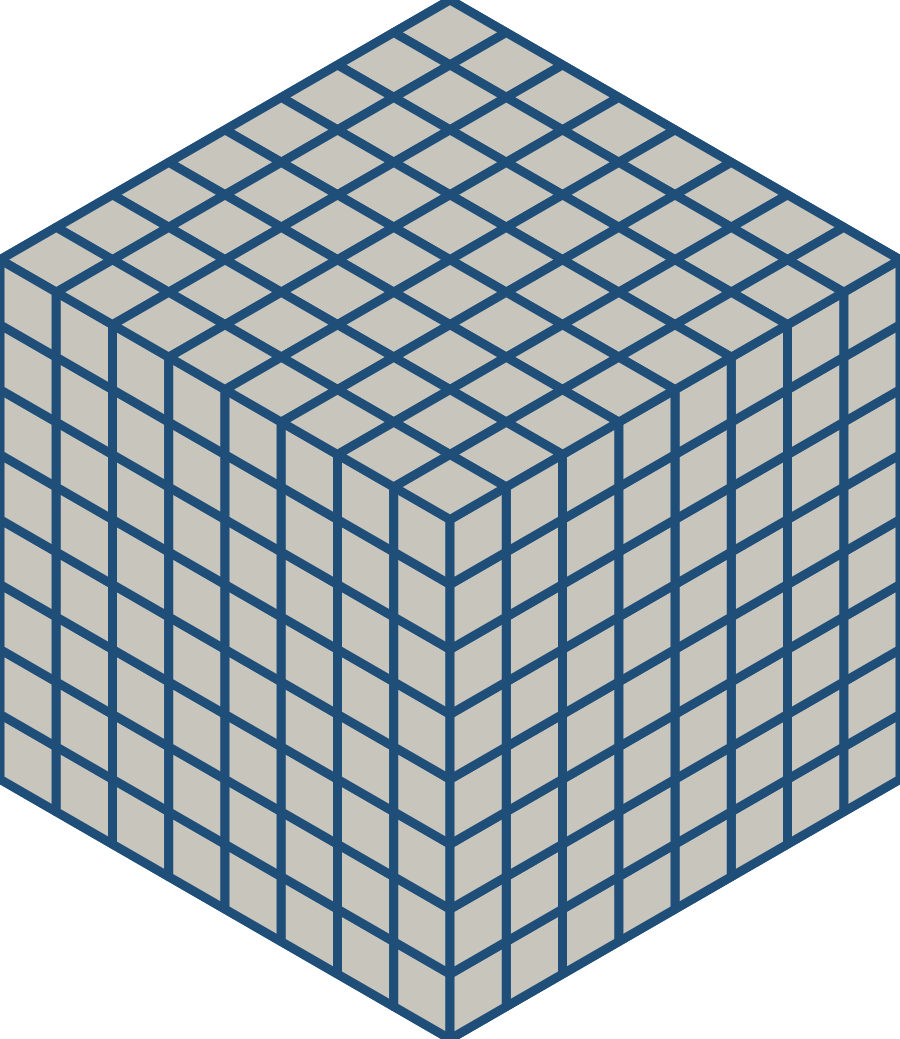

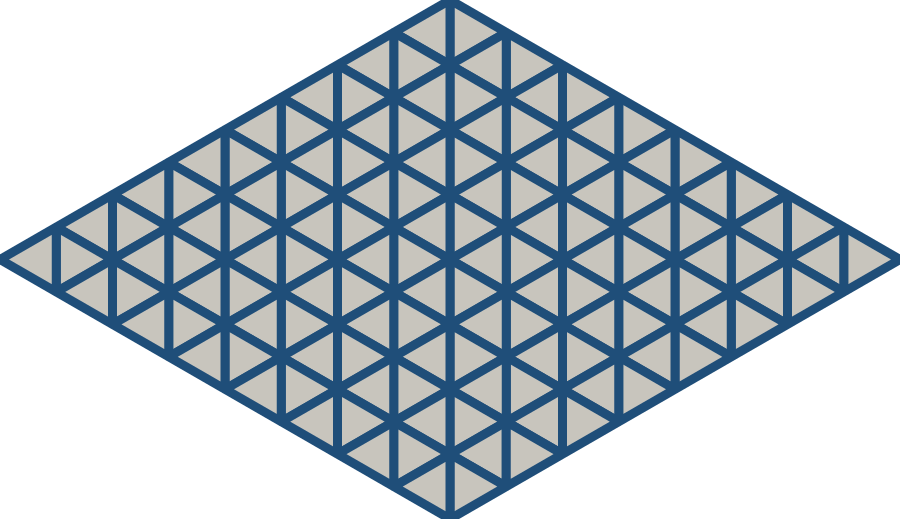

section: 289 points, 128 faces


In [26]:
// slice: the planar cross-section of a mesh. The input is simplexified
// (marching tetrahedra), so a volume mesh -> a triangle/quad surface one
// dimension lower; unlike crop (which keeps whole cells on one side), slice
// computes the intersection itself.
Mesh sliceVol = hex_block(8, 1.0 / 8.0);
{
    NDArray field(DType::Float64, {sliceVol.NumPoints()});
    const double* p = sliceVol.Points().As<double>();
    double* fd = field.As<double>();
    for (std::size_t i = 0; i < sliceVol.NumPoints(); ++i)
        fd[i] = std::sin(6.0 * p[i * 3]) * std::cos(6.0 * p[i * 3 + 1]) + p[i * 3 + 2];
    sliceVol.AddPointData("f", std::move(field));
}

SliceOptions sliceOpts;
sliceOpts.mOrigin = {0.5, 0.5, 0.5};
sliceOpts.mNormal = {0.0, 0.0, 1.0};
Mesh sliceSection = slice(sliceVol, sliceOpts);

std::size_t sliceFaces = 0;
for (auto cb : sliceSection.CellRange()) sliceFaces += cb.NumCells();
std::cout << "section: " << sliceSection.NumPoints() << " points, " << sliceFaces << " faces\n";

// the source volume (skinned) and its mid-plane section, both coloured by f
xcpp::display(render(sliceVol, "f", "viridis"));
xcpp::display(render(sliceSection, "f", "viridis"));


## Isosurfaces / contours

`isosurface` computes the **level set** of a scalar `point_data` field — the locus where the array equals a given isovalue, one topological dimension below the cut cells. It is the *data-driven* sibling of `slice`, and goes through the same `detail/marching.hpp` cutter: slice cuts where `dot(x - origin, normal)` is zero, isosurface where `f(x) - isovalue` is. Several isovalues land in one mesh, cut in ascending order and tagged per cell with a Float64 `iso:value` and an Int64 `iso:index`; the contoured field reads back as **exactly** the isovalue on the cut points. A `cell_data` name is rejected — it is piecewise constant and has no level set.


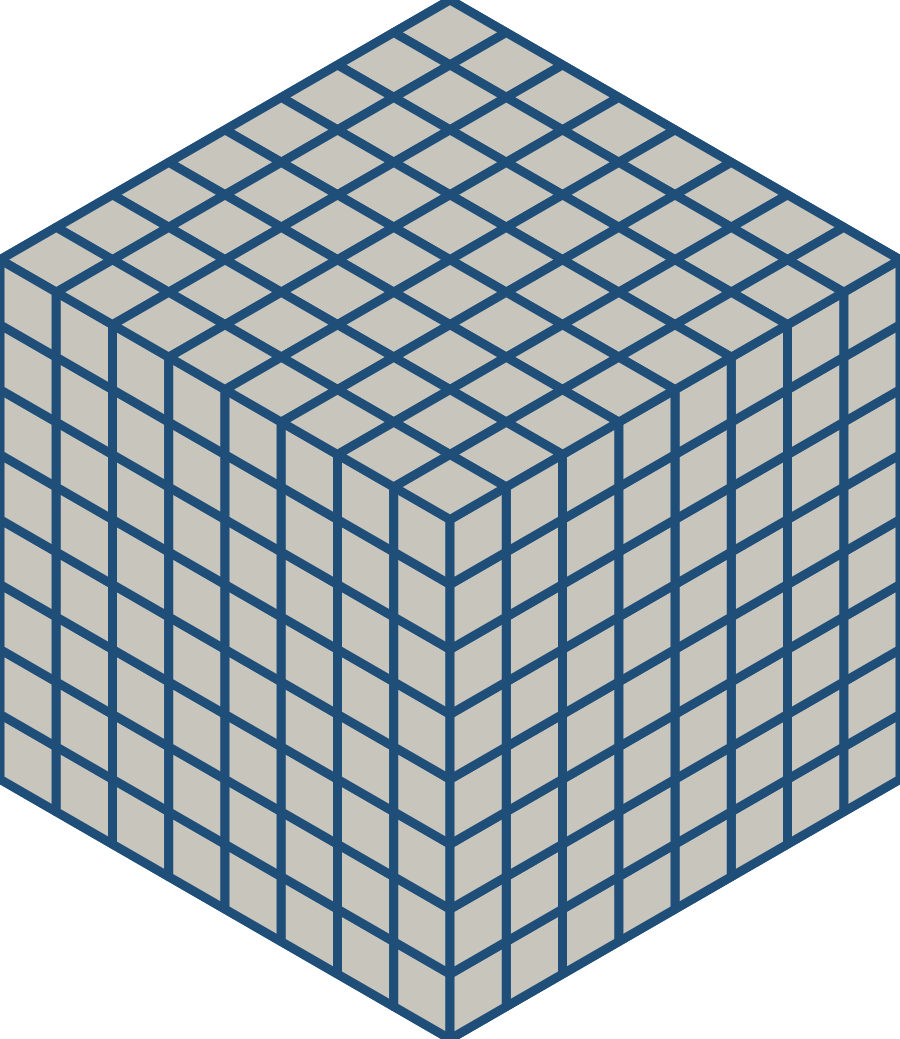

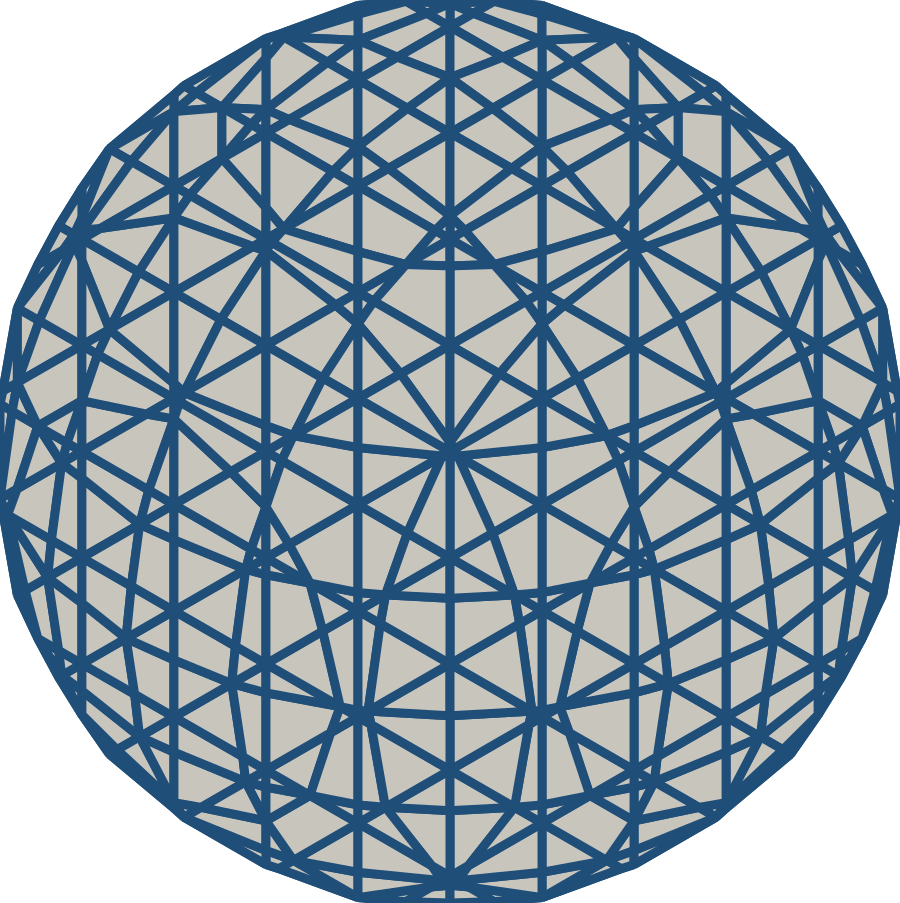

contours: 1206 points, 1836 faces
distinct values of r on the contours: 0.2 0.32 0.44
  contour 0: 228 faces
  contour 1: 588 faces
  contour 2: 1020 faces


In [27]:
// isosurface: the level set of a scalar point_data field. Three nested
// contours of a radial field on the same hex block, all in one mesh, tagged
// per cell with iso:value (the level) and iso:index (its ordinal).
Mesh isoVol = hex_block(8, 1.0 / 8.0);
{
    NDArray radius(DType::Float64, {isoVol.NumPoints()});
    const double* p = isoVol.Points().As<double>();
    double* rd = radius.As<double>();
    for (std::size_t i = 0; i < isoVol.NumPoints(); ++i) {
        const double dx = p[i * 3] - 0.5, dy = p[i * 3 + 1] - 0.5, dz = p[i * 3 + 2] - 0.5;
        rd[i] = std::sqrt(dx * dx + dy * dy + dz * dz);
    }
    isoVol.AddPointData("r", std::move(radius));
}

IsosurfaceOptions isoOpts;
isoOpts.mArrayName = "r";
isoOpts.mIsovalues = {0.20, 0.32, 0.44};
Mesh isoShells = isosurface(isoVol, isoOpts);

std::size_t isoFaces = 0;
for (auto cb : isoShells.CellRange()) isoFaces += cb.NumCells();
std::cout << "contours: " << isoShells.NumPoints() << " points, " << isoFaces << " faces\n";

// The contoured field is written exactly, not merely interpolated close: every
// contour point reads back as one of the three requested levels.
{
    const NDArray& rr = isoShells.PointData("r");
    std::vector<double> levels(rr.As<double>(), rr.As<double>() + rr.Size());
    std::sort(levels.begin(), levels.end());
    levels.erase(std::unique(levels.begin(), levels.end()), levels.end());
    std::cout << "distinct values of r on the contours:";
    for (double v : levels) std::cout << " " << v;
    std::cout << "\n";
}

// iso:index is the integer tag split() needs -- one mesh per contour.
SplitResult isoPieces = split(isoShells, SplitBy::Tag, "iso:index");
for (auto& piece : isoPieces.mPieces) {
    std::size_t n = 0;
    for (auto cb : piece.mMesh.CellRange()) n += cb.NumCells();
    std::cout << "  contour " << piece.mKey << ": " << n << " faces\n";
}

// the source volume and its three nested level sets, coloured by the field
xcpp::display(render(isoVol, "r", "turbo"));
xcpp::display(render(isoShells, "r", "turbo"));


## Field derivatives — gradient, divergence, curl

`gradient` differentiates a `point_data` field: its **gradient**, **divergence** or **curl**. Everything above transforms, transfers, summarizes or contours a field; this is what lets us *differentiate* one — the missing input for contouring a **derived** quantity and for gradient-based error indicators driving `refine`.

**Green-Gauss** (the default) applies the divergence theorem over the cell, fanning each face into triangles about its corner average: exact for a linear field on *any* cell, planar faces or not. **Least-squares** fits over the cells sharing a node and falls back to Green-Gauss — counted, never silently wrong — on a degenerate neighbourhood. Unlike every other operation here it changes no geometry: it attaches one array. See [`doc/gradient.md`](../../doc/gradient.md).

In [28]:
// gradient: the gradient / divergence / curl of a point_data field. Start with
// the exactness guarantee on a field whose answer we know: for f = 3x - 2y + 5z
// the gradient is the constant (3, -2, 5), and Green-Gauss reproduces it
// exactly -- on any cell, warped faces included.
Mesh gradVol = hex_block(8, 1.0 / 8.0);
{
    NDArray f(DType::Float64, {gradVol.NumPoints()});
    const double* p = gradVol.Points().As<double>();
    double* fd = f.As<double>();
    for (std::size_t i = 0; i < gradVol.NumPoints(); ++i)
        fd[i] = 3.0 * p[i * 3] - 2.0 * p[i * 3 + 1] + 5.0 * p[i * 3 + 2] + 7.0;
    gradVol.AddPointData("f", std::move(f));
}

GradientOptions gradOpts;
gradOpts.mArrayName = "f";
GradientResult gradLinear = gradient(gradVol, gradOpts);
{
    const NDArray& g = gradLinear.mMesh.CellData("f:gradient", 0);
    const double* gd = g.As<double>();
    std::cout << "grad of a linear field: (" << gd[0] << ", " << gd[1] << ", " << gd[2]
              << ")  -- exact answer (3, -2, 5)\n";
    std::cout << "components per cell: " << g.Shape()[1] << ", cells skipped: "
              << gradLinear.mNumSkipped << ", fell back: " << gradLinear.mNumFallback << "\n";
}

// A vector field: curl of u = (7z, 11x, 13y) is the constant (13, 7, 11) --
// three distinct nonzero components, so no index permutation could hide.
{
    NDArray u(DType::Float64, {gradVol.NumPoints(), 3});
    const double* p = gradVol.Points().As<double>();
    double* ud = u.As<double>();
    for (std::size_t i = 0; i < gradVol.NumPoints(); ++i) {
        ud[i * 3 + 0] = 7.0 * p[i * 3 + 2];
        ud[i * 3 + 1] = 11.0 * p[i * 3 + 0];
        ud[i * 3 + 2] = 13.0 * p[i * 3 + 1];
    }
    gradVol.AddPointData("u", std::move(u));
}
GradientOptions curlOpts;
curlOpts.mArrayName = "u";
curlOpts.mOperator = GradientOperator::Curl;
GradientResult curlRes = gradient(gradVol, curlOpts);
{
    const double* cd = curlRes.mMesh.CellData("u:curl", 0).As<double>();
    std::cout << "curl u = (" << cd[0] << ", " << cd[1] << ", " << cd[2]
              << ")  -- exact answer (13, 7, 11)\n";
}


grad of a linear field: (3, -2, 5)  -- exact answer (3, -2, 5)
components per cell: 3, cells skipped: 0, fell back: 0
curl u = (13, 7, 11)  -- exact answer (13, 7, 11)


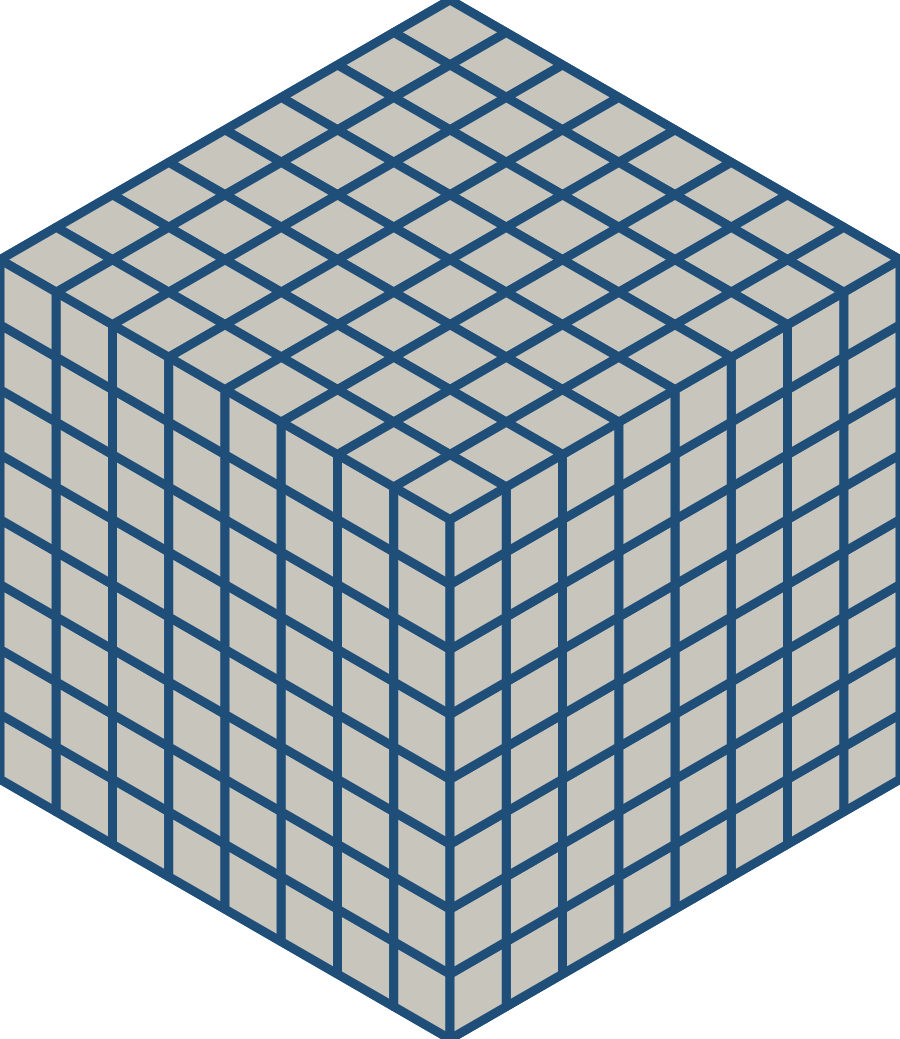

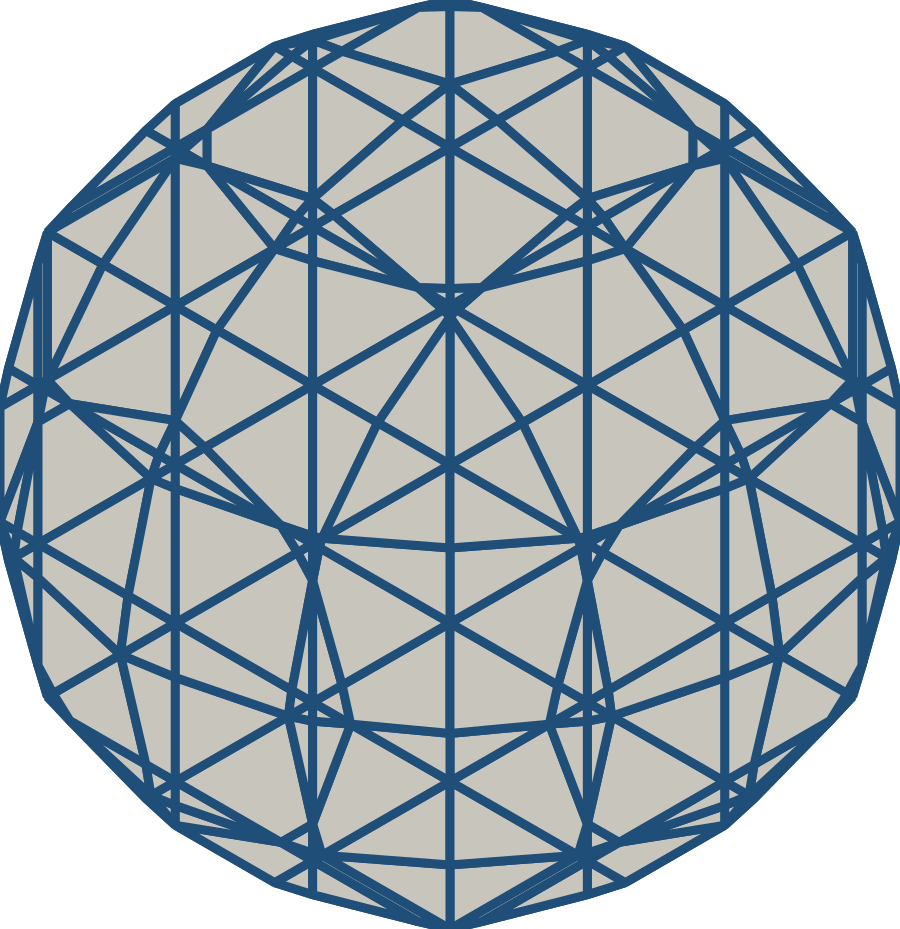

isosurface of |grad r2|: 326 points, 516 faces


In [29]:
// The composition this exists for: colour a mesh by the magnitude of the
// gradient of a NON-linear field, then contour that derived quantity.
Mesh gradRadial = hex_block(8, 1.0 / 8.0);
{
    NDArray r(DType::Float64, {gradRadial.NumPoints()});
    const double* p = gradRadial.Points().As<double>();
    double* rd = r.As<double>();
    for (std::size_t i = 0; i < gradRadial.NumPoints(); ++i) {
        const double dx = p[i * 3] - 0.5, dy = p[i * 3 + 1] - 0.5, dz = p[i * 3 + 2] - 0.5;
        rd[i] = dx * dx + dy * dy + dz * dz;   // r^2, so |grad| = 2r grows outward
    }
    gradRadial.AddPointData("r2", std::move(r));
}

GradientOptions pointOpts;
pointOpts.mArrayName = "r2";
pointOpts.mLocation = DataLocation::Point;   // isosurface needs point_data
Mesh withGrad = gradient(gradRadial, pointOpts).mMesh;

// The magnitude of the (n, 3) gradient, as a scalar we can contour and colour by.
{
    const NDArray& g = withGrad.PointData("r2:gradient");
    const double* gd = g.As<double>();
    NDArray mag(DType::Float64, {withGrad.NumPoints()});
    double* md = mag.As<double>();
    for (std::size_t i = 0; i < withGrad.NumPoints(); ++i)
        md[i] = std::sqrt(gd[i * 3] * gd[i * 3] + gd[i * 3 + 1] * gd[i * 3 + 1] +
                          gd[i * 3 + 2] * gd[i * 3 + 2]);
    withGrad.AddPointData("gradmag", std::move(mag));
}

IsosurfaceOptions derivedOpts;
derivedOpts.mArrayName = "gradmag";
derivedOpts.mIsovalues = {0.6};
Mesh derivedContour = isosurface(withGrad, derivedOpts);
std::size_t derivedFaces = 0;
for (auto cb : derivedContour.CellRange()) derivedFaces += cb.NumCells();
std::cout << "isosurface of |grad r2|: " << derivedContour.NumPoints() << " points, "
          << derivedFaces << " faces\n";

// A vector figure's size scales with facet count, so render the skin of the
// coloured volume rather than every interior cell (the same trade-off the
// earlier cells make).
Mesh gradSkin = extract_surface(withGrad);
xcpp::display(render(gradSkin, "gradmag", "turbo"));
xcpp::display(render(derivedContour, "gradmag", "turbo"));


Every operation shown here is also exposed through the C API, the Fortran
module, and the WebAssembly build, and as a `meshioplusplus` CLI verb.

## Data operations

The operations above reshape *geometry*. The **data operations** act on
`point_data`/`cell_data`/`field_data` and never touch geometry. A quick
walk through all five on the surface mesh.

In [30]:
// operate on the cropped vizCorner (not the full ~58k-cell surface), so the
// renders below stay a legible size
Mesh surfD = vizCorner;
{
    const double* p = surfD.Points().As<double>();
    double cx = 0, cy = 0;
    for (std::size_t i = 0; i < surfD.NumPoints(); ++i) { cx += p[i*3]; cy += p[i*3+1]; }
    cx /= surfD.NumPoints(); cy /= surfD.NumPoints();

    NDArray vel(DType::Float64, {surfD.NumPoints(), 3});
    NDArray height2(DType::Float64, {surfD.NumPoints()});
    double* vd = vel.As<double>();
    double* hd = height2.As<double>();
    for (std::size_t i = 0; i < surfD.NumPoints(); ++i) {
        double rx = p[i*3]-cx, ry = p[i*3+1]-cy, rz = p[i*3+2];
        vd[i*3+0] = -ry; vd[i*3+1] = rx; vd[i*3+2] = 0.3 * rz;
        hd[i] = p[i*3+2];
    }
    surfD.AddPointData("velocity", std::move(vel));
    surfD.AddPointData("height", std::move(height2));
}

auto show_data_info = [](const Mesh& m, const std::string& title) {
    DataInfoReport rows = data_info(m);
    std::cout << title << "\n";
    for (auto& a : rows.mArrays)
        std::cout << "  " << data_location_name(a.mLocation) << " " << a.mName << " comp=" << a.mNumComponents
                  << " entries=" << a.mNumEntries << " min=" << a.mMin << " max=" << a.mMax << " mean=" << a.mMean
                  << "\n";
    return rows;
};
show_data_info(surfD, "before:");

before:
  point_data height comp=1 entries=71 min=0 max=0.125244 mean=0.045108
  point_data velocity comp=3 entries=71 min=-0.102238 max=0.099902 mean=0.0045108


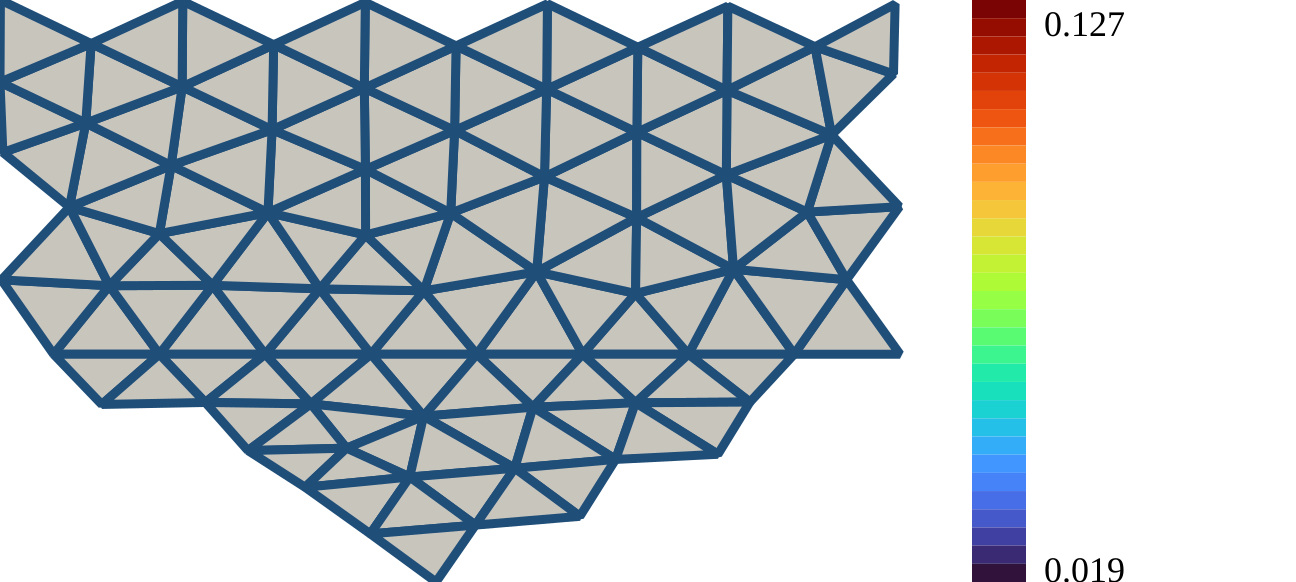

speed range: 0.0158867 -> 0.135876


In [31]:
// data_calc: a small expression language (+ - * /, abs/sqrt/min/max/norm).
DataCalcOptions calcOpts;
calcOpts.location = DataLocation::Point;
calcOpts.output = "speed";
Mesh withSpeed = data_calc(surfD, "norm(velocity)", calcOpts);
const double* sp2 = withSpeed.PointData("speed").As<double>();
double smin = *std::min_element(sp2, sp2 + withSpeed.NumPoints());
double smax = *std::max_element(sp2, sp2 + withSpeed.NumPoints());
std::cout << "speed range: " << smin << " -> " << smax << "\n";
xcpp::display(render(withSpeed, "speed", "turbo", true));

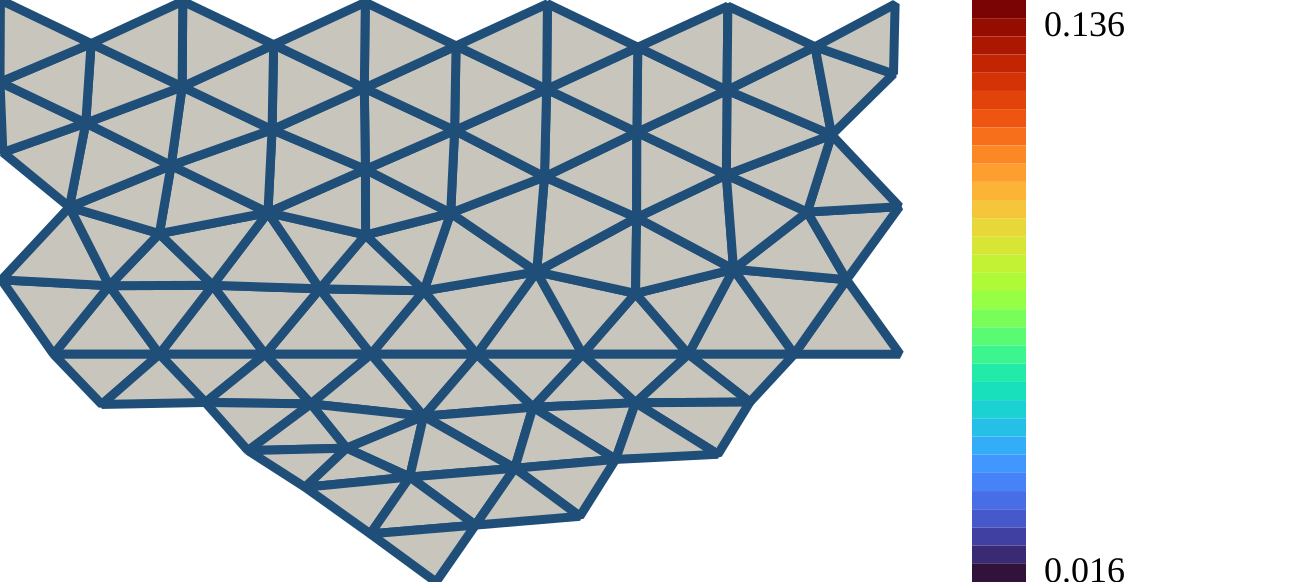

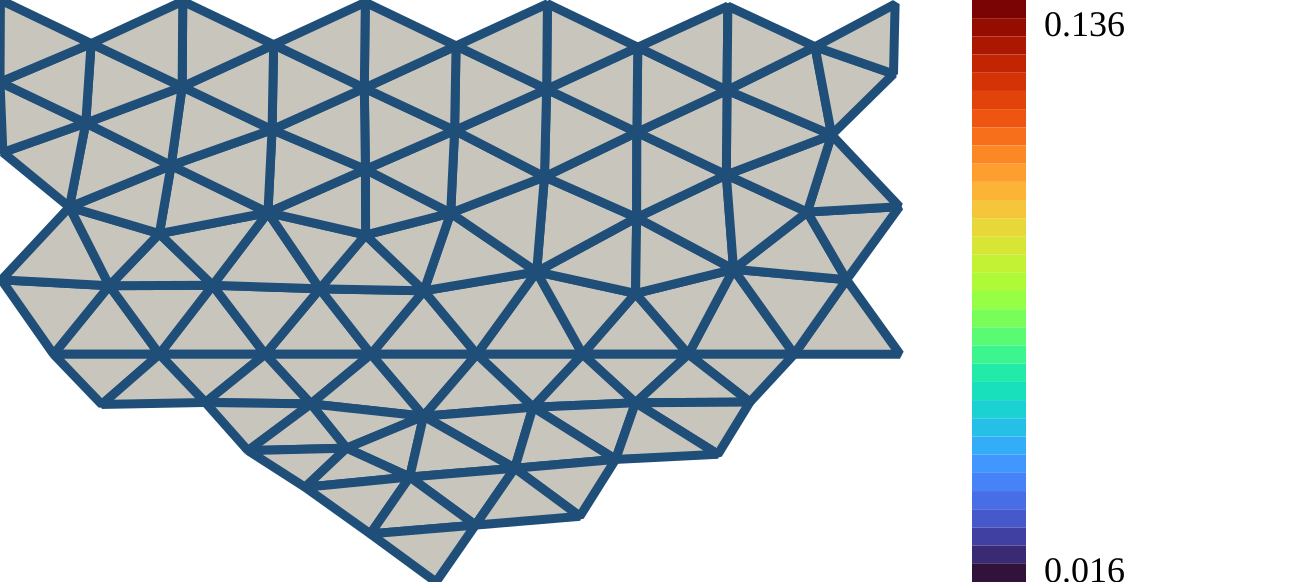

In [32]:
// point_data_to_cell_data / cell_data_to_point_data: move between locations.
// The round trip acts as a smoothing pass.
DataAverageOptions avgOpts; avgOpts.names = {"speed"}; avgOpts.suffix = "_cell";
Mesh toCell = point_data_to_cell_data(withSpeed, avgOpts);
DataAverageOptions backOpts; backOpts.names = {"speed_cell"}; backOpts.weight = CellPointWeight::Measure;
Mesh back2 = cell_data_to_point_data(toCell, backOpts);
xcpp::display(render(withSpeed, "speed", "turbo", true, smin, smax));
xcpp::display(render(back2, "speed_cell", "turbo", true, smin, smax));

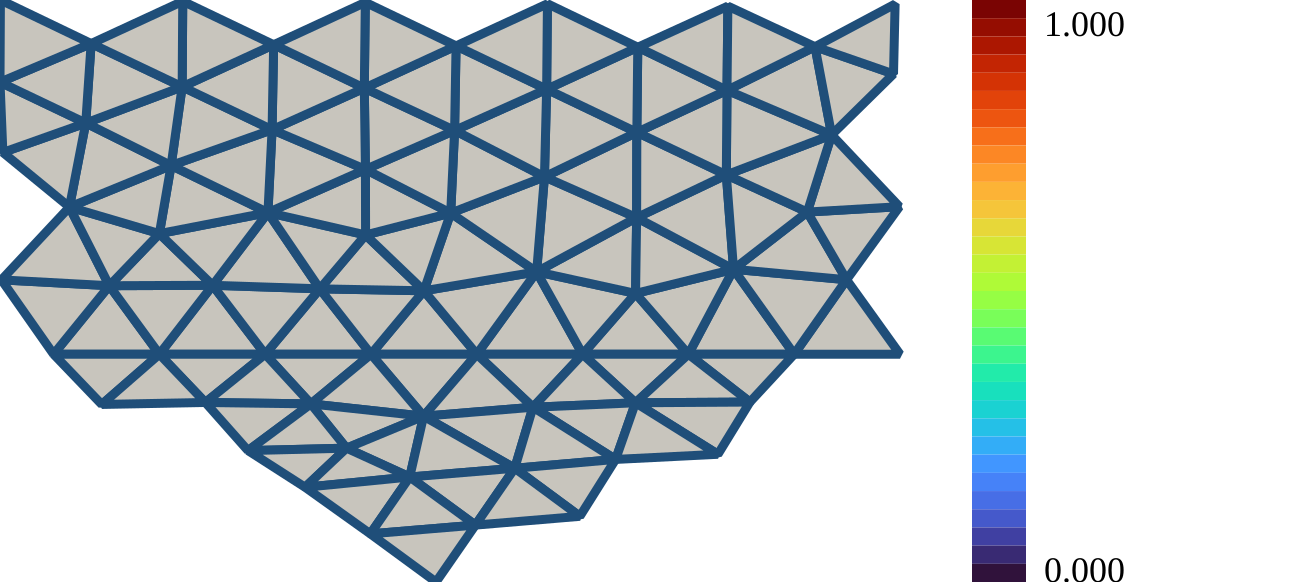

normalized range: 0 -> 1


In [33]:
// data_condition: clamp / normalize / standardize, without touching geometry.
DataConditionOptions condOpts;
condOpts.location = DataLocation::Point;
condOpts.names = {"speed"};
condOpts.mode = ConditionMode::Normalize;
condOpts.suffix = "_n";
Mesh normd = data_condition(withSpeed, condOpts);
const double* nd = normd.PointData("speed_n").As<double>();
std::cout << "normalized range: " << *std::min_element(nd, nd + normd.NumPoints()) << " -> "
          << *std::max_element(nd, nd + normd.NumPoints()) << "\n";
xcpp::display(render(normd, "speed_n", "turbo", true, 0.0, 1.0));

In [34]:
// data_manage: rename / drop / keep. Tidy up and confirm the geometry never moved.
Mesh tidy = data_rename(normd, DataLocation::Point, "speed_n", "speed_normalized");
tidy = data_drop(tidy, DataLocation::Point, {"speed"}, false);
show_data_info(tidy, "after rename + drop:");

bool same_pts = surfD.NumPoints() == tidy.NumPoints();
bool same_cells = surfD.Cells(0).NumCells() == tidy.Cells(0).NumCells();
std::cout << "\ngeometry unchanged -- points: " << std::boolalpha << same_pts << " | cell count: " << same_cells << "\n";

after rename + drop:
  point_data height comp=1 entries=71 min=0 max=0.125244 mean=0.045108
  point_data speed_normalized comp=1 entries=71 min=0 max=1 mean=0.478844
  point_data velocity comp=3 entries=71 min=-0.102238 max=0.099902 mean=0.0045108

geometry unchanged -- points: true | cell count: true


## Transient sequences (multi-file datasets)

Most formats cannot express time at all, so transient solver output usually
arrives as a *set* of files &mdash; `out_0000.vtu … out_0500.vtu`. The
sequence layer treats such a set as **one ordered dataset**: `sequence_expand`
builds the plan, `sequence_read_step` reads exactly one step at a time,
`sequence_to_timeseries` fans a set **in** to one multi-step XDMF, and
`timeseries_to_sequence` fans one **out** to a file per step.

Two things are contracts rather than conveniences. Ordering is
**natural-numeric**, so `out_10.vtu` follows `out_9.vtu` (a lexicographic sort
gets that backwards). And the drivers **stream**: at most one `Mesh` is alive
at a time, so a 500-step dataset costs no more memory than a one-step one.

The XDMF writer here uses the `"XML"` data format, since the amalgamation is
built without HDF5 &mdash; one self-contained file, no `.h5` companion.

In [35]:
// A synthetic time series: the hex block, oscillating along z.
Mesh seqBase = hex_block(4);
const std::string seqDir = "/tmp/mio_nb_seq";
std::filesystem::remove_all(seqDir);
std::filesystem::create_directories(seqDir);

const int nSteps = 12;
for (int k = 0; k < nSteps; ++k) {
    Mesh step = hex_block(4);
    NDArray pts = step.Points();
    double* p = pts.As<double>();
    NDArray height(DType::Float64, {step.NumPoints()});
    double* h = height.As<double>();
    const double dz = 1.5 * std::sin(2.0 * M_PI * k / nSteps);
    for (std::size_t i = 0; i < step.NumPoints(); ++i) {
        p[i * 3 + 2] += dz;
        h[i] = p[i * 3 + 2];
    }
    step.AddPointData("height", std::move(height));
    // Deliberately UNPADDED names, so the ordering rule has something to prove.
    write_vtu(seqDir + "/out_" + std::to_string(k) + ".vtu", step, true, false);
}

SequenceInput seqIn;
seqIn.mPattern = seqDir + "/out_*.vtu";
std::vector<SequenceEntry> seqPlan = sequence_expand(seqIn);

std::cout << seqPlan.size() << " steps, in natural-numeric order:\n  ";
for (const SequenceEntry& e : seqPlan)
    std::cout << std::filesystem::path(e.mPath).filename().string() << ' ';
std::cout << "\n  times:";
for (const SequenceEntry& e : seqPlan) std::cout << ' ' << e.mTime;
std::cout << "  (source: " << sequence_time_source_name(seqPlan[0].mTimeSource) << ")\n";
std::cout << "  a lexicographic sort would put out_10 third, not last.\n";

12 steps, in natural-numeric order:
  out_0.vtu out_1.vtu out_2.vtu out_3.vtu out_4.vtu out_5.vtu out_6.vtu out_7.vtu out_8.vtu out_9.vtu out_10.vtu out_11.vtu 
  times: 0 1 2 3 4 5 6 7 8 9 10 11  (source: filename)
  a lexicographic sort would put out_10 third, not last.


In [36]:
// Fan-in: 12 single-step files -> one multi-step XDMF, streaming.
SequenceOutput seqSeries;
seqSeries.mPath = seqDir + "/series.xdmf";
seqSeries.mOptions.mEncoding = WriteEncoding::Ascii;   // "XML": no HDF5 needed
sequence_to_timeseries(seqIn, seqSeries);

SequenceInput backIn;
backIn.mPaths = {seqSeries.mPath};
std::vector<SequenceEntry> seriesPlan = sequence_expand(backIn);
std::cout << "fan-in -> series.xdmf (" << seriesPlan.size()
          << " steps; times now come from the file itself: "
          << sequence_time_source_name(seriesPlan[3].mTimeSource) << ")\n";

// Fan-out: back to one file per step, {step} zero-padded to four digits.
// SequenceOutput::mOptions goes through registry_write_ex, so the codec is
// selectable per run -- needed here because VTU's registry default bakes in
// zlib, which this amalgamation is built without.
SequenceOutput fanned;
fanned.mPath = seqDir + "/step_{step}.vtu";
fanned.mOptions.mCodec = detail::VtkCodec::None;
fanned.mOptions.mCodecSet = true;
timeseries_to_sequence(seqSeries.mPath, "", ReadOptions{}, fanned);
std::cout << "fan-out -> " << sequence_expand_pattern(fanned.mPath, 0, seriesPlan.size())
          << " ... " << sequence_expand_pattern(fanned.mPath, 11, seriesPlan.size()) << "\n";

// A transient post-processing run: the chain is applied to EVERY step.
SequencePipeline seqPipe;
seqPipe.mInput = seqIn;
seqPipe.mSteps.push_back({"Quality", {}});
seqPipe.mOutput.mPath = seqDir + "/post_{step}.vtu";
seqPipe.mOutput.mOptions.mCodec = detail::VtkCodec::None;
seqPipe.mOutput.mOptions.mCodecSet = true;
PipelineReport seqReport = run_sequence_pipeline(seqPipe);
std::cout << "per-step pipeline: " << seqReport.mSteps.size()
          << " step-operations over " << seqPlan.size() << " files\n";

fan-in -> series.xdmf (12 steps; times now come from the file itself: file)
fan-out -> /tmp/mio_nb_seq/step_0000.vtu ... /tmp/mio_nb_seq/step_0011.vtu
per-step pipeline: 12 step-operations over 12 files


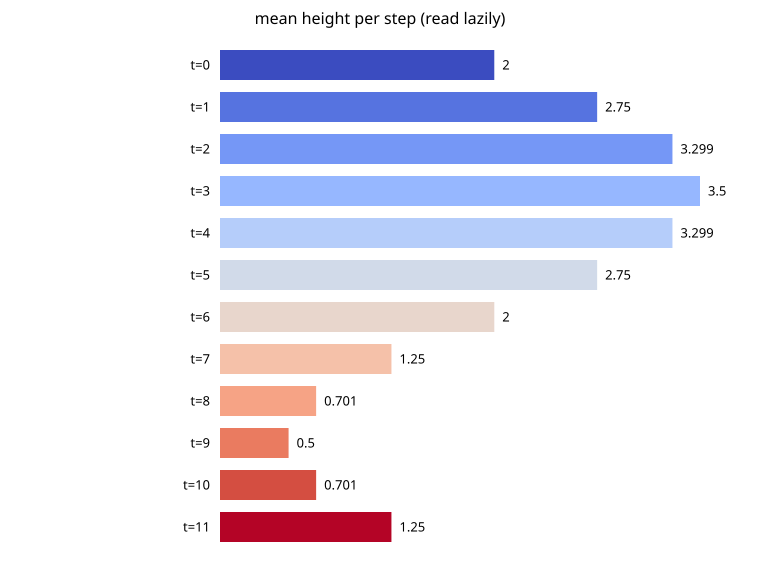

In [37]:
// The series as one figure: each step's mean height, read lazily -- only one
// mesh is ever alive. Then three frames rendered from the fanned-out files.
std::vector<double> seqTimes, seqMeans;
for (std::size_t i = 0; i < seriesPlan.size(); ++i) {
    Mesh step = sequence_read_step(seriesPlan, i, "", ReadOptions{});
    const double* h = step.PointData("height").As<double>();
    double sum = 0.0;
    for (std::size_t j = 0; j < step.NumPoints(); ++j) sum += h[j];
    seqTimes.push_back(seriesPlan[i].mTime);
    seqMeans.push_back(sum / static_cast<double>(step.NumPoints()));
}

std::vector<std::string> seqLabels;
for (double t : seqTimes) seqLabels.push_back("t=" + std::to_string(static_cast<int>(t)));
xcpp::display(bar_chart(seqLabels, seqMeans, "mean height per step (read lazily)", "coolwarm"));

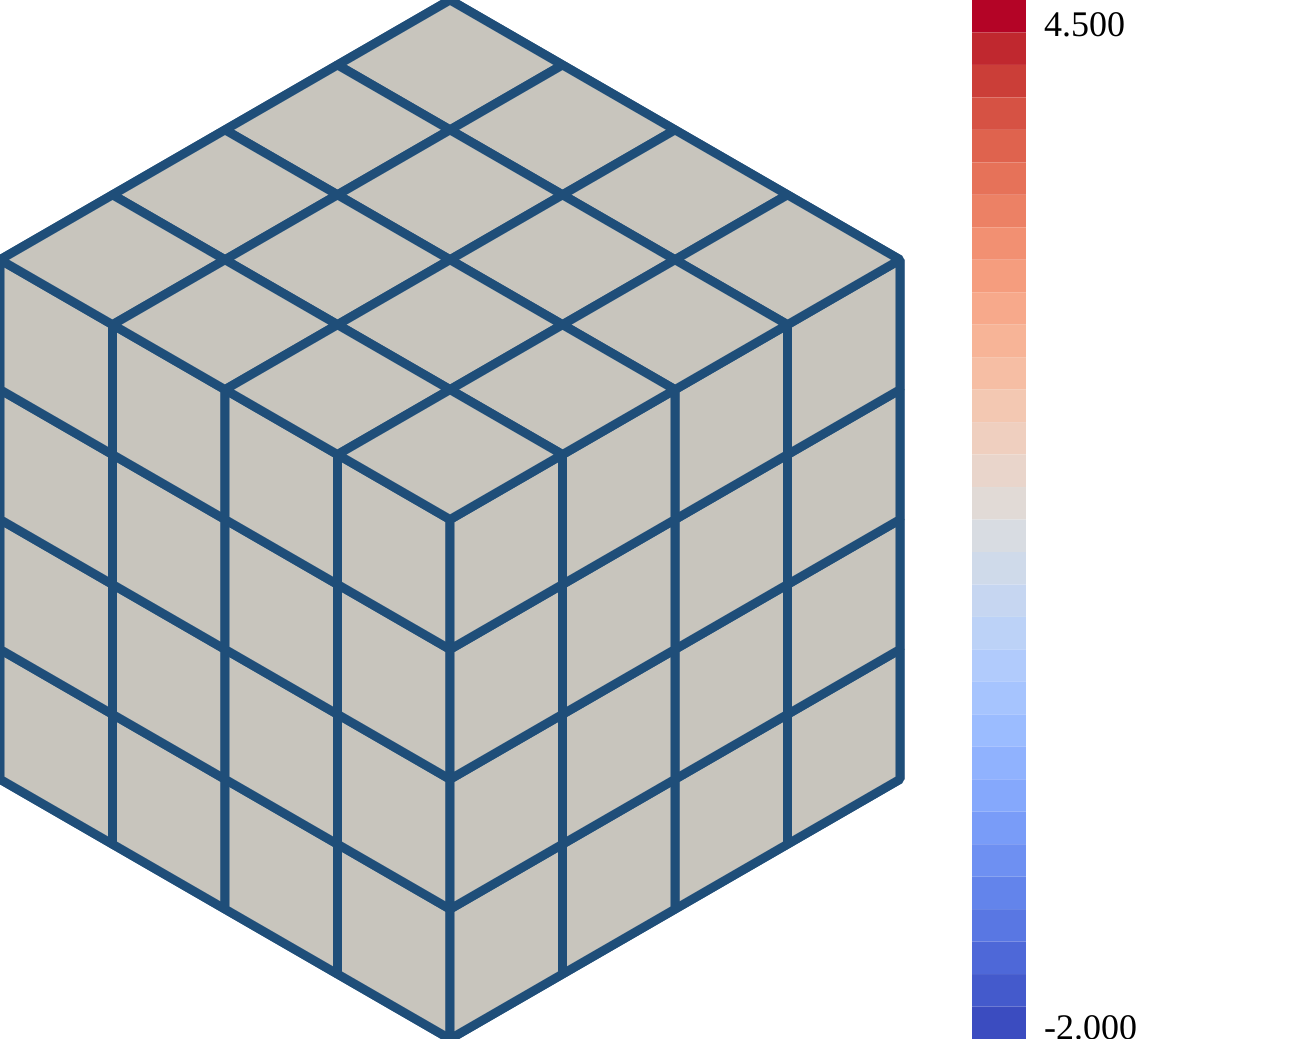

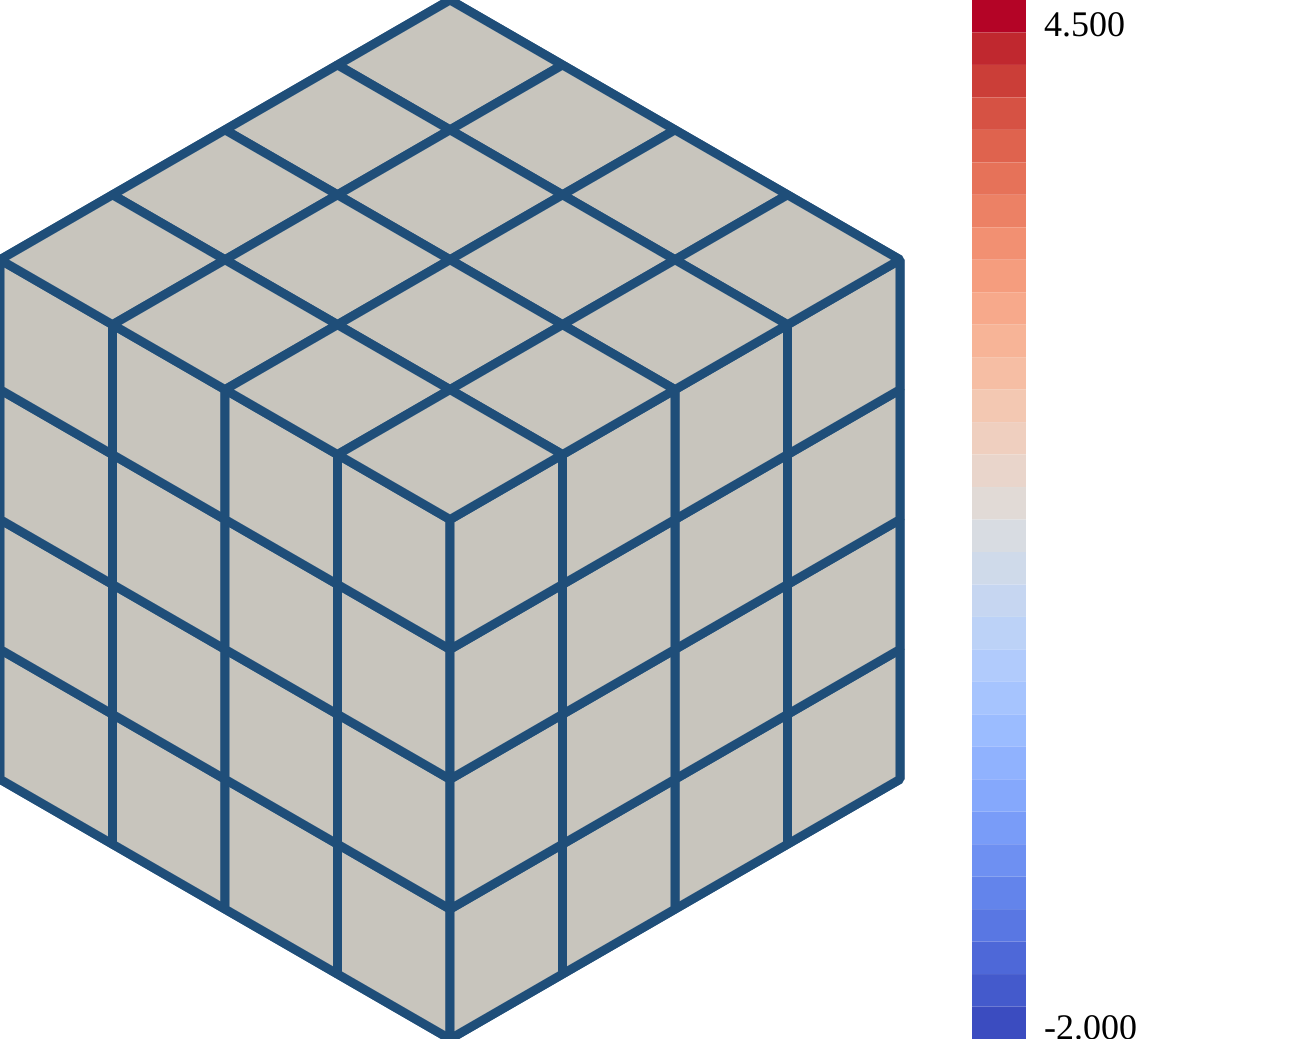

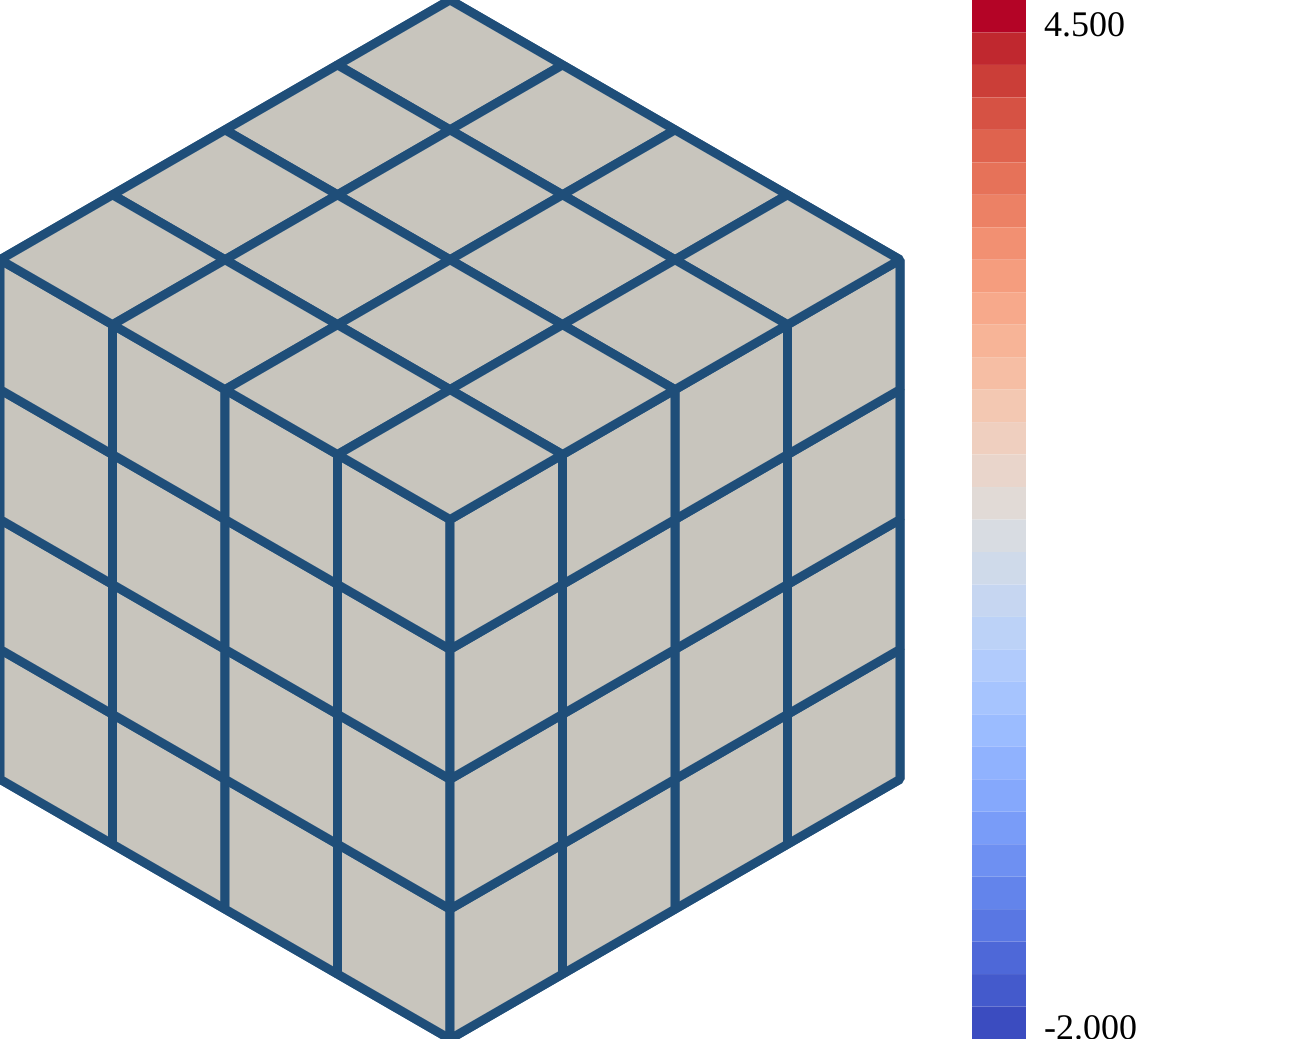

t = 0
t = 3
t = 6


In [38]:
// Three frames from the fanned-out files, coloured by the field that moves.
for (int k : {0, 3, 6}) {
    Mesh frame = read_vtu(sequence_expand_pattern(seqDir + "/step_{step}.vtu", k, nSteps));
    std::cout << "t = " << seqTimes[k] << '\n';
    xcpp::display(render(frame, "height", "coolwarm", true, -2.0, 4.5));
}

## Selective reads: loading only what you need

Two `ReadOptions` narrow a read: `mPointsOnly` (geometry only, no data
arrays) and `mDataArrays` (only the named arrays). `registry_read_metadata`
skips the heavy arrays entirely and reports whether it had to fall back to
a full read (`mFellBackToFullRead`).

In [39]:
Mesh selMesh = mesh;
{
    const double* p = selMesh.Points().As<double>();
    double cx=0, cy=0, cz=0;
    for (std::size_t i = 0; i < selMesh.NumPoints(); ++i) { cx+=p[i*3]; cy+=p[i*3+1]; cz+=p[i*3+2]; }
    cx/=selMesh.NumPoints(); cy/=selMesh.NumPoints(); cz/=selMesh.NumPoints();
    NDArray radius(DType::Float64, {selMesh.NumPoints()});
    double* rd = radius.As<double>();
    for (std::size_t i = 0; i < selMesh.NumPoints(); ++i) {
        double dx=p[i*3]-cx, dy=p[i*3+1]-cy, dz=p[i*3+2]-cz;
        rd[i] = std::sqrt(dx*dx+dy*dy+dz*dz);
    }
    selMesh.AddPointData("radius", std::move(radius));
}
std::string selPath = "/tmp/mio_nb_selective.vtu";
write_vtu(selPath, selMesh, true, false);

ReadOptions bareOpts; bareOpts.mPointsOnly = true;

double tFull = 1e300, tBare = 1e300, tMeta = 1e300;
Mesh full, bare;
MeshMetadata meta;
for (int i = 0; i < 5; ++i) {
    auto t0 = std::chrono::steady_clock::now();
    full = registry_read(selPath, "vtu", {});
    tFull = std::min(tFull, std::chrono::duration<double, std::milli>(std::chrono::steady_clock::now() - t0).count());
}
for (int i = 0; i < 5; ++i) {
    auto t0 = std::chrono::steady_clock::now();
    bare = registry_read(selPath, "vtu", bareOpts);
    tBare = std::min(tBare, std::chrono::duration<double, std::milli>(std::chrono::steady_clock::now() - t0).count());
}
for (int i = 0; i < 5; ++i) {
    auto t0 = std::chrono::steady_clock::now();
    meta = registry_read_metadata(selPath, "vtu", {});
    tMeta = std::min(tMeta, std::chrono::duration<double, std::milli>(std::chrono::steady_clock::now() - t0).count());
}

std::cout << "full read       " << tFull << " ms   point_data arrays=" << full.NumPointData() << "\n";
std::cout << "points_only     " << tBare << " ms   point_data arrays=" << bare.NumPointData() << "\n";
std::cout << "read_metadata   " << tMeta << " ms   " << meta.mNumPoints << " points, " << meta.NumCells()
          << " cells, arrays=" << meta.mPointDataNames.size() << "\n";
std::cout << "summary was cheap: " << std::boolalpha << !meta.mFellBackToFullRead << "\n";

std::cout << "\nsame geometry, no data arrays: " << std::boolalpha << (bare.NumPointData() == 0) << "\n";

full read       196.619 ms   point_data arrays=1
points_only     193.34 ms   point_data arrays=0
read_metadata   54.2761 ms   52282 points, 293408 cells, arrays=1
summary was cheap: true

same geometry, no data arrays: true


Reading the numbers honestly: on *this* file `points_only` saves only a
little, because `example.vtu` is geometry-dominated — its one point-data
array is small next to ~290k cells of connectivity, and connectivity is
never skipped. `read_metadata()` is the consistent win: it decodes neither
coordinates nor connectivity, only the array headers.